# Avance 1: Análisis Exploratorio de Datos (EDA)

**Proyecto integrador** — conjunto de datos **InHARD**.

## Qué es este avance (texto de la actividad)

Este primer avance consiste en realizar un **análisis exploratorio de datos (EDA)**, es decir, **describir los datos** mediante **técnicas estadísticas y de visualización** (análisis **univariante** y **bi/multivariante**) para enfocarse en los aspectos más relevantes, y **aplicar y justificar operaciones de preprocesamiento** relacionadas con **valores faltantes**, **atípicos** y **alta cardinalidad**, incluyendo **conclusiones** que identifiquen **tendencias o relaciones importantes**.

---

## Metodología: CRISP-ML(Q)

El EDA apoya la fase de **comprensión de los datos** dentro de **CRISP-ML(Q)** y prepara decisiones de **modelado** y **evaluación** (por ejemplo, métricas robustas al desequilibrio y validación por sesión).

### Preguntas guía que aborda esta libreta

- ¿Hay valores faltantes? ¿Patrones de ausencia?
- ¿Estadísticas resumidas (numéricas y categóricas)?
- ¿Valores atípicos?
- ¿Cardinalidad de categóricas?
- ¿Distribuciones sesgadas? ¿Transformaciones?
- ¿Tendencias temporales (según columnas de tiempo del índice)?
- ¿Correlación entre numéricas? ¿Relación con la variable objetivo?
- ¿Distribución por categorías (bivariado)?
- ¿Normalización de imágenes? (nota: esta entrega es tabular; se comenta el caso RGB)
- ¿Desequilibrio de clases en la objetivo?

## 1. Setup

In [172]:
# Global set up & libraries loading (PEP 8).
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TARGET_VARIABLE = 'Meta_action_label'

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('ggplot')

sns.set_theme(style='whitegrid', context='talk', font_scale=0.95)
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print('Initial setup completed. TARGET_VARIABLE =', repr(TARGET_VARIABLE))


Initial setup completed. TARGET_VARIABLE = 'Meta_action_label'


## 2. Data Load

In [173]:
LOCAL_PATH = Path(r'D:\Dataset In Hard\01-InHARD.7z\Segmented')
FILE_PATH = LOCAL_PATH / 'InHARD.csv'

df = pd.read_csv(FILE_PATH)
if '' in df.columns:
    df = df.rename(columns={'': 'unknown'})

print('Ruta:', FILE_PATH)

Ruta: D:\Dataset In Hard\01-InHARD.7z\Segmented\InHARD.csv


In [174]:
df.head(10)

,Unnamed: 0,Action_end_bvh_frame,Action_end_rgb_frame,Action_end_rgb_sec,Action_label,Action_start_bvh_frame,Action_start_rgb_frame,Action_start_rgb_sec,Duration_sec,File,Meta_action_class_number,Meta_action_label,Operation,Recurrence,Subject
0,0,1071,270,9.00,[OP010] Consult sheets,324,82,2.72,6.28,P01_R01,2,Consult sheets,OP010,R01,P01
1,1,1528,385,12.84,[OP010] Catch Fixture key LARD,1343,338,11.28,1.56,P01_R01,7,Picking left,OP010,R01,P01
2,2,2247,566,18.88,[OP010] Place LARD on Profile P360-1,1647,415,13.84,5.04,P01_R01,12,Assemble system,OP010,R01,P01
3,3,3028,762,25.44,[OP010] Catch Fixation FIXA1,2776,699,23.32,2.12,P01_R01,6,Picking in front,OP010,R01,P01
4,4,3428,863,28.80,[OP010] Place FIXA1 on LARD at 160mm,3152,794,26.48,2.32,P01_R01,12,Assemble system,OP010,R01,P01
5,5,3857,971,32.40,[OP010] Catch Bolt B820,3719,936,31.24,1.16,P01_R01,7,Picking left,OP010,R01,P01
6,6,4514,1136,37.92,[OP010] Take measuring rod,4352,1096,36.56,1.36,P01_R01,8,Take measuring rod,OP010,R01,P01
7,7,4809,1211,40.40,[OP010] Take screwdriver,4685,1180,39.36,1.04,P01_R01,4,Take screwdriver,OP010,R01,P01
8,8,5304,1335,44.56,[OP010] Screw FIXA1 with B820,4904,1235,41.20,3.36,P01_R01,12,Assemble system,OP010,R01,P01
9,9,5623,1416,47.24,[OP010] Put down screwdriver,5328,1341,44.76,2.48,P01_R01,5,Put down screwdriver,OP010,R01,P01


## 3. Exploratory Data Analysis (EDA)

In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5303 entries, 0 to 5302
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                5303 non-null   int64  
 1   Action_end_bvh_frame      5303 non-null   int64  
 2   Action_end_rgb_frame      5303 non-null   int64  
 3   Action_end_rgb_sec        5303 non-null   float64
 4   Action_label              5303 non-null   str    
 5   Action_start_bvh_frame    5303 non-null   int64  
 6   Action_start_rgb_frame    5303 non-null   int64  
 7   Action_start_rgb_sec      5303 non-null   float64
 8   Duration_sec              5303 non-null   float64
 9   File                      5303 non-null   str    
 10  Meta_action_class_number  5303 non-null   int64  
 11  Meta_action_label         5303 non-null   str    
 12  Operation                 5303 non-null   str    
 13  Recurrence                5303 non-null   str    
 14  Subject            

In [176]:
def get_df_summary(df):
    # Get basic info: number of records and columns (dataframe shape)
    print(f'Data Summary:\n - Records: {df.shape[0]:,}\n - Columns: {df.shape[1]}\n')
    
    # Identify & display NaN values and data types
    data = pd.DataFrame({
        'Data Type': df.dtypes,
        'NaN (#)': df.isna().sum(),
        'NaN (%)': (df.isna().sum() / len(df) * 100).round(2)
    })
    
    return data.sort_values(by='NaN (#)', ascending=False)

summary_details = get_df_summary(df)
display(summary_details)

Data Summary:
 - Records: 5,303
 - Columns: 15



,Data Type,NaN (#),NaN (%)
Unnamed: 0,int64,0,0.0
Action_end_bvh_frame,int64,0,0.0
Action_end_rgb_frame,int64,0,0.0
Action_end_rgb_sec,float64,0,0.0
Action_label,str,0,0.0
Action_start_bvh_frame,int64,0,0.0
Action_start_rgb_frame,int64,0,0.0
Action_start_rgb_sec,float64,0,0.0
Duration_sec,float64,0,0.0
File,str,0,0.0


In [177]:
# Separate categorical and numerical columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

### Descriptive Statistics: Numerical

In [178]:
print(f'Count of Numerical Columns: {len(num_cols)}')

Count of Numerical Columns: 9


In [179]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,5303.0,2380.876296,1397.183952,0.00,1164.00,2360.00,3599.500000,4802.00
Action_end_bvh_frame,5303.0,26121.089006,18204.994487,252.00,11335.00,23696.00,37390.500000,104697.00
Action_end_rgb_frame,5303.0,6577.231378,4583.683270,64.00,2854.50,5968.00,9413.000000,26354.00
Action_end_rgb_sec,5303.0,219.460592,152.942317,2.12,95.24,199.12,314.079995,879.36
Action_start_bvh_frame,5303.0,25833.565529,18175.053228,29.00,11035.00,23397.00,37024.000000,103163.00
Action_start_rgb_frame,5303.0,6504.838205,4576.144748,7.00,2778.00,5891.00,9329.000000,25968.00
Action_start_rgb_sec,5303.0,217.044850,152.690887,0.24,92.70,196.56,311.280005,866.48
Duration_sec,5303.0,2.415742,1.768832,0.12,1.40,2.00,2.920000,26.96
Meta_action_class_number,5303.0,7.618141,4.022329,0.00,5.00,7.00,12.000000,14.00


In [180]:
def get_distribution_summary(df, cols):
    print('Skewness & Kurtosis Summary:')
    num_cols = df[cols]
    
    # Identify & display Skew & Kurtosis for numerical columns
    data = pd.DataFrame({
        'Skewness': num_cols.skew(),
        'Kurtosis': num_cols.kurtosis()
    })

    data['Skew Analysis'] = data['Skewness'].apply(
        lambda x: 'Right (+)' if x > 0.5 else ('Left (-)' if x < -0.5 else 'Simmetric')
    )
    
    data['Kurtosis Analysis'] = data['Kurtosis'].apply(
        lambda k: 'Leptokurtic (High)' if k > 1 else 
                ('Platykurtic (Low)' if k < -1 else 'Mesokurtic (Normal)')
    )
    
    return data.sort_values(by='Skewness', ascending=False)

summary_details = get_distribution_summary(df, num_cols)
display(summary_details)

Skewness & Kurtosis Summary:


,Skewness,Kurtosis,Skew Analysis,Kurtosis Analysis
Duration_sec,3.080592,20.684918,Right (+),Leptokurtic (High)
Action_end_bvh_frame,0.898206,0.810239,Right (+),Mesokurtic (Normal)
Action_end_rgb_sec,0.897877,0.809151,Right (+),Mesokurtic (Normal)
Action_end_rgb_frame,0.897876,0.809142,Right (+),Mesokurtic (Normal)
Action_start_bvh_frame,0.897684,0.804861,Right (+),Mesokurtic (Normal)
Action_start_rgb_sec,0.897354,0.803768,Right (+),Mesokurtic (Normal)
Action_start_rgb_frame,0.897349,0.803756,Right (+),Mesokurtic (Normal)
Unnamed: 0,0.022099,-1.221517,Simmetric,Platykurtic (Low)
Meta_action_class_number,-0.383576,-1.020217,Simmetric,Platykurtic (Low)


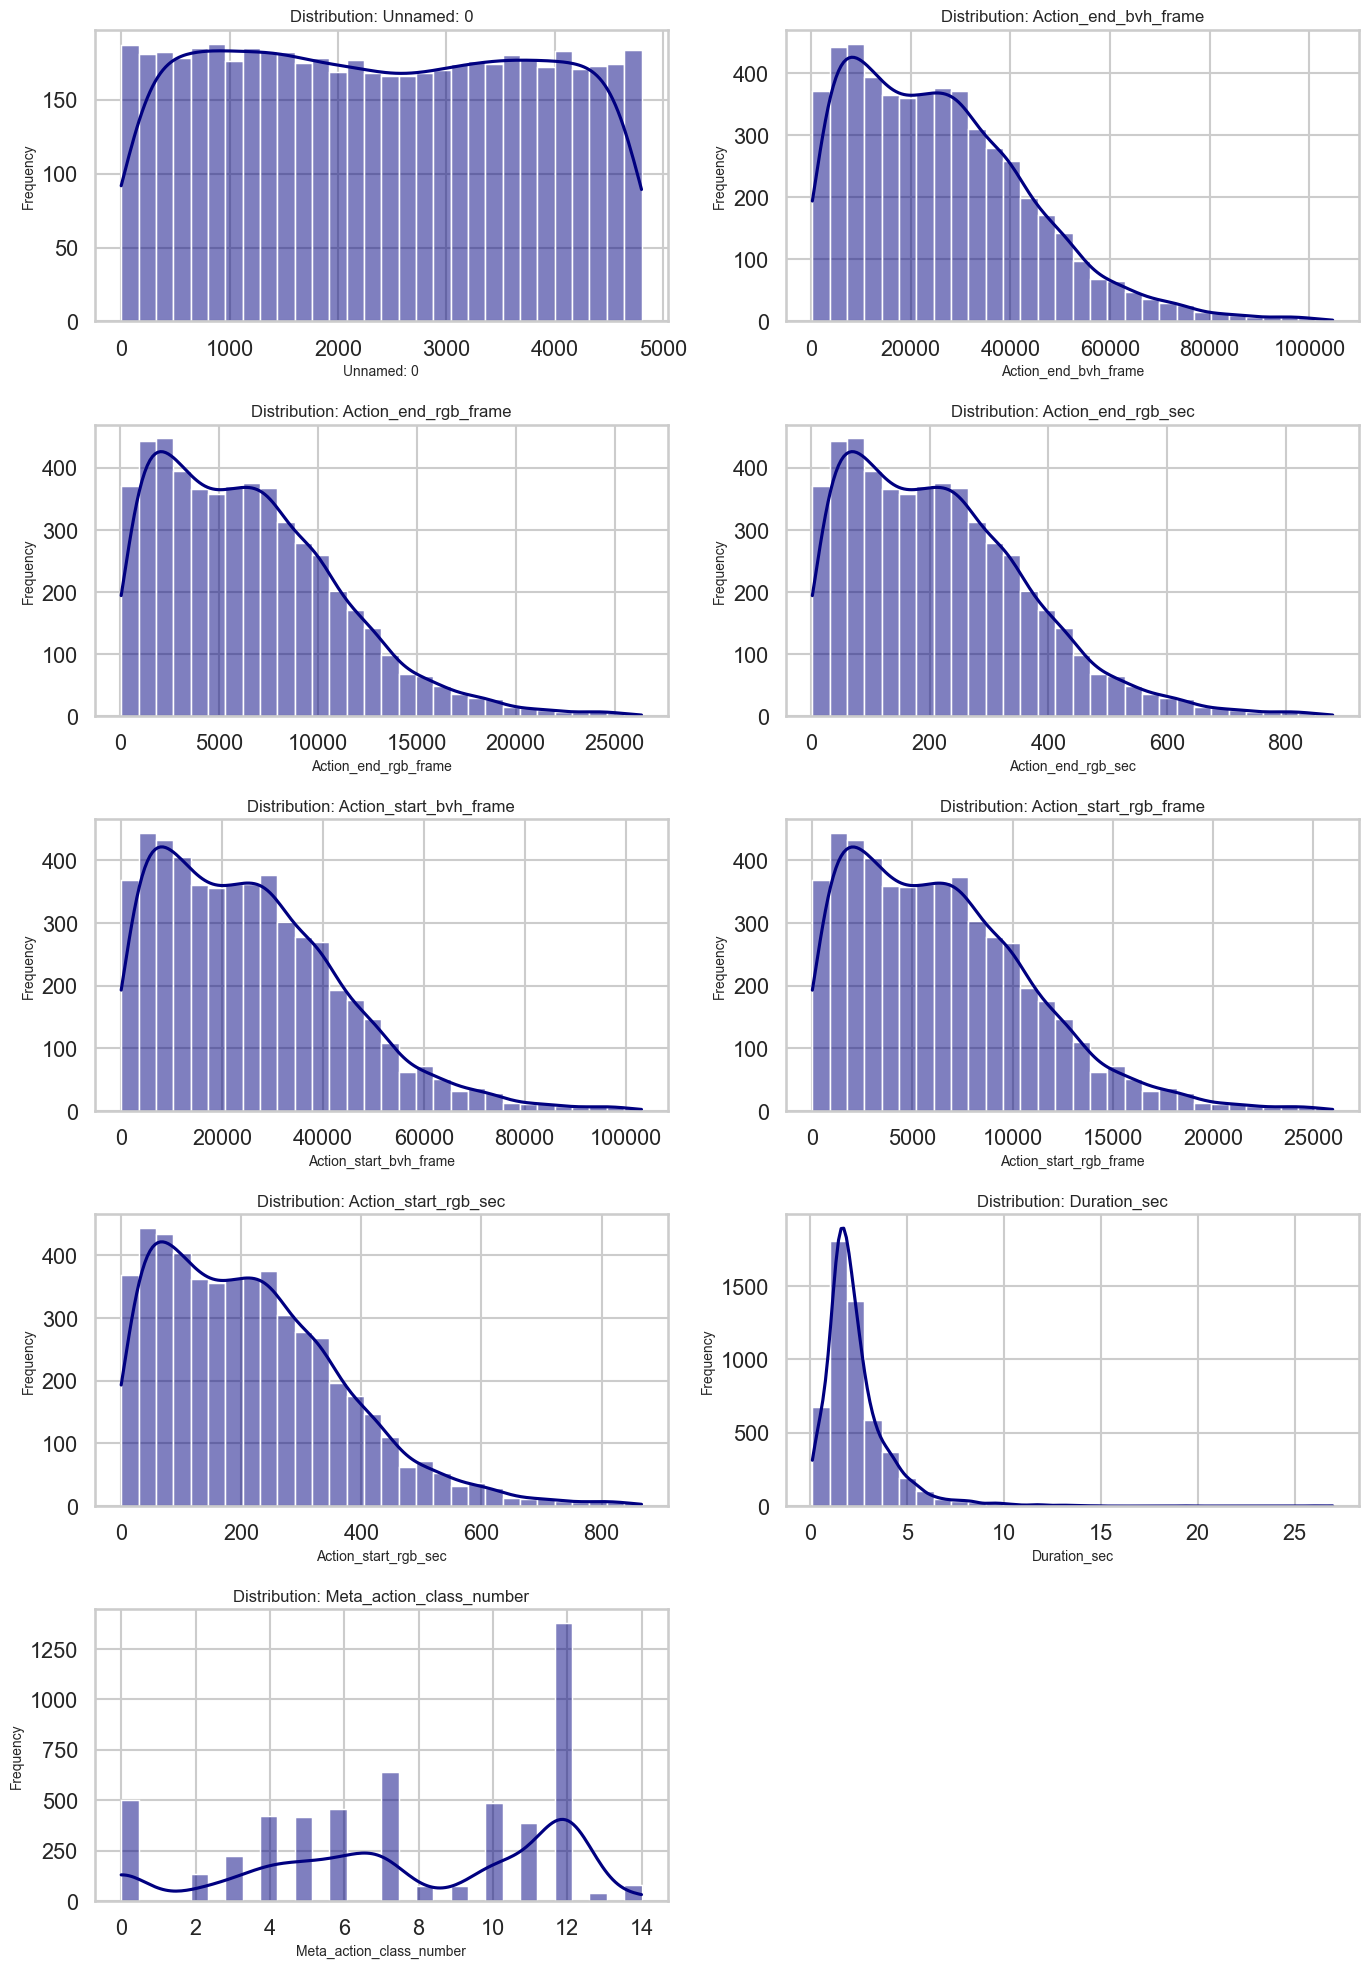

In [181]:
def plot_histograms(df, cols):
    n_cols = 2
    n_rows = (len(cols) + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
    axes = axes.flatten()

    for i, col_name in enumerate(cols):
        sns.histplot(
            data=df, 
            x=col_name, 
            kde=True, 
            ax=axes[i], 
            color='navy', 
            bins=30
        )
        axes[i].set_title(f'Distribution: {col_name}')
        axes[i].set_ylabel('Frequency')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_histograms(df, num_cols)

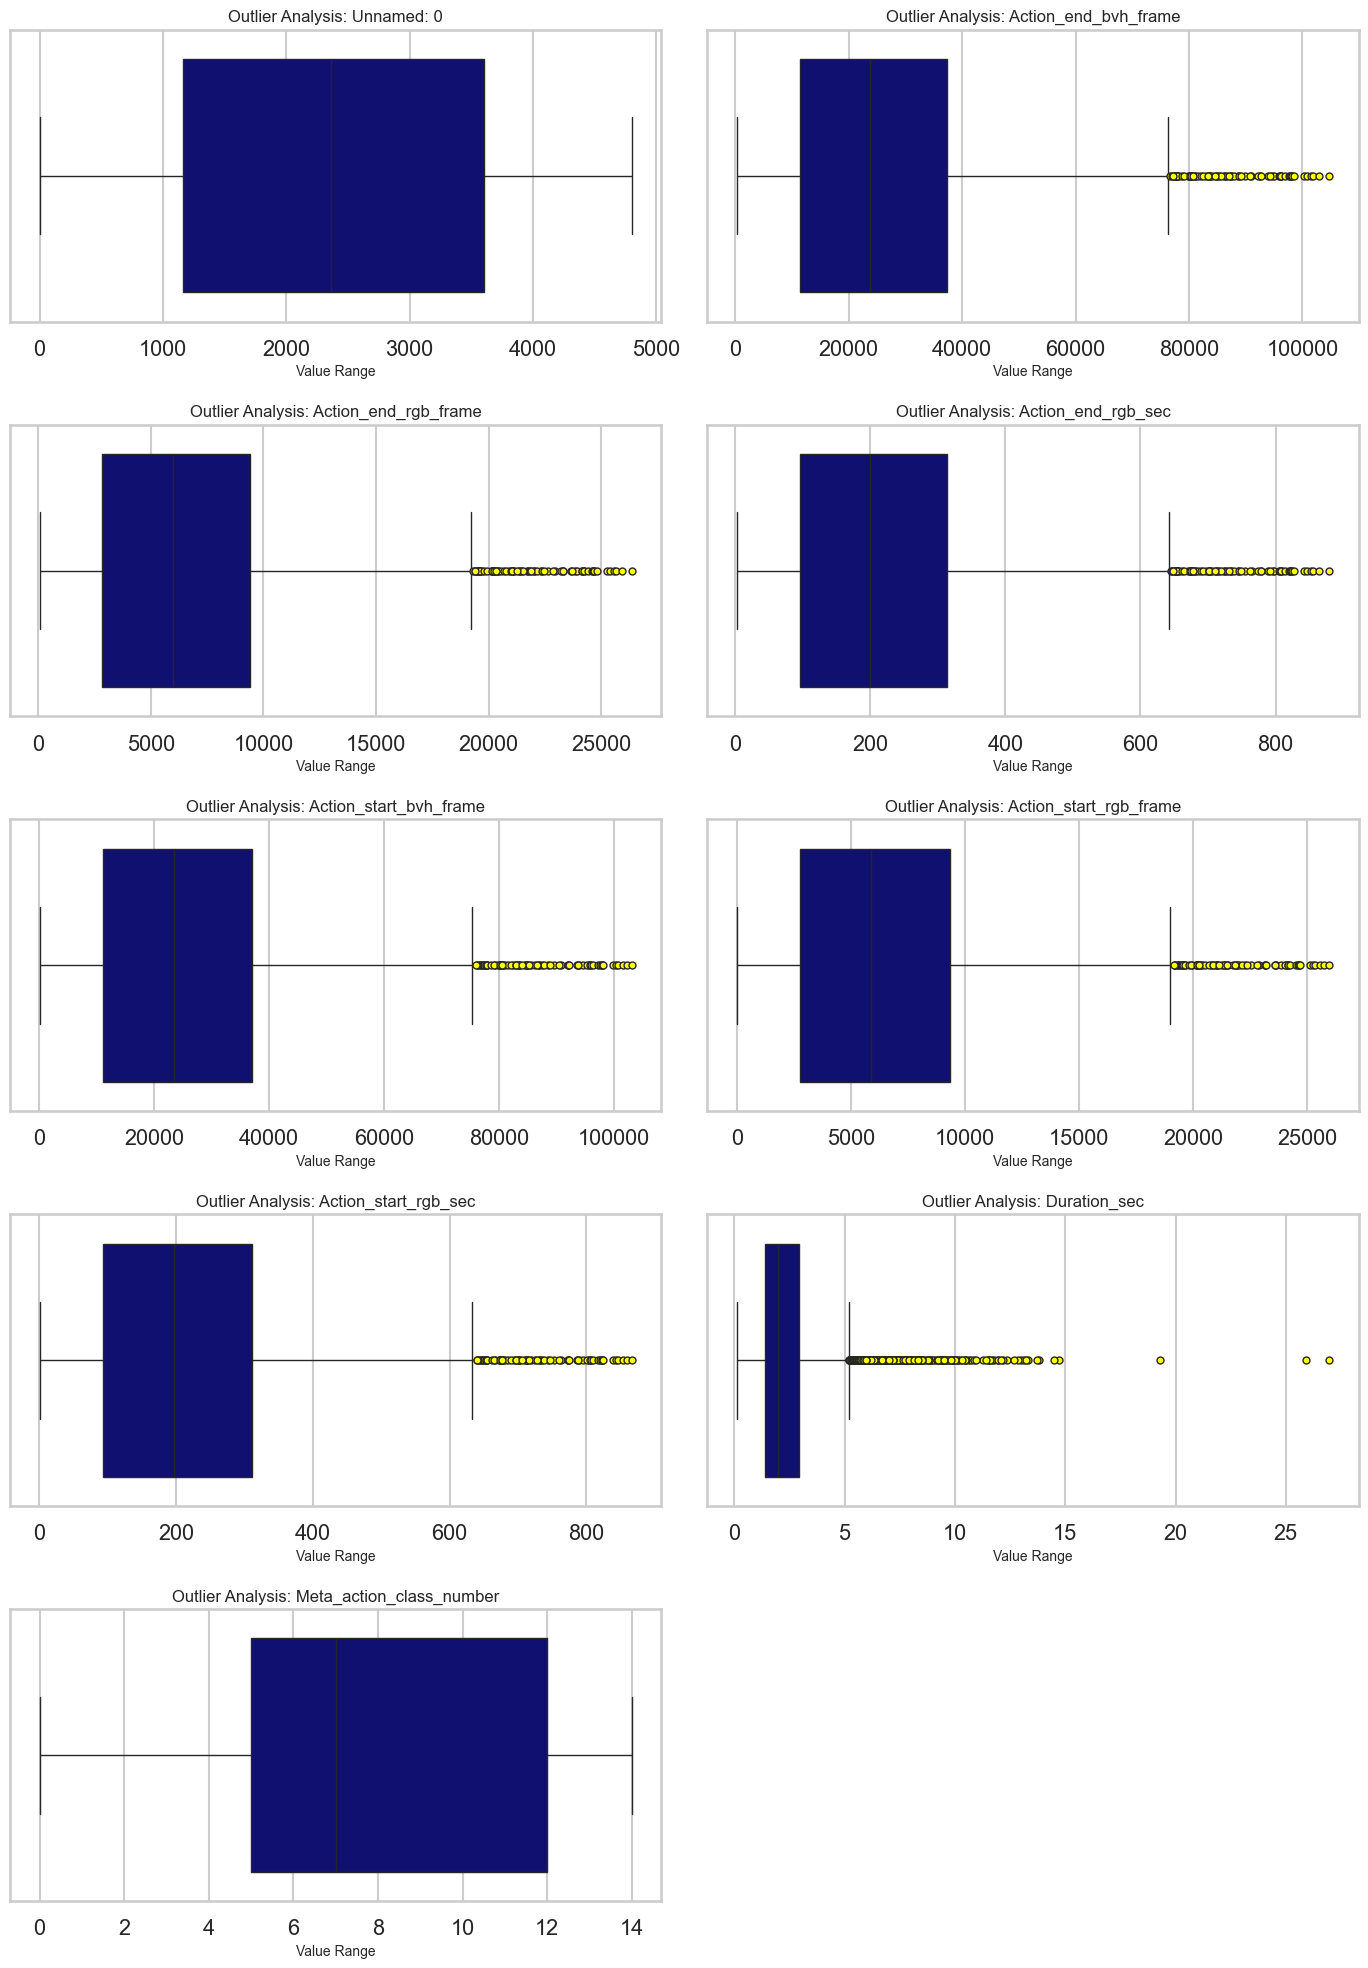

In [182]:
def plot_boxplots(df, cols):
    n_cols = 2
    n_rows = (len(cols) + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
    axes = axes.flatten()

    for i, col_name in enumerate(cols):
        sns.boxplot(
            data=df, 
            x=col_name,
            ax=axes[i], 
            color='navy',
            flierprops={'markerfacecolor': 'yellow', 'marker': 'o', 'markersize': 5} # Highlight outliers
        )
        axes[i].set_title(f'Outlier Analysis: {col_name}', fontsize=12)
        axes[i].set_xlabel('Value Range')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_boxplots(df, num_cols)

In [183]:
def get_outliers(df, cols):
    outlier_data = []

    for col_name in cols:
        # Calculate IQR and limits
        q1 = df[col_name].quantile(0.25)
        q3 = df[col_name].quantile(0.75)
        iqr = q3 - q1
        
        upper_limit = q3 + 1.5 * iqr
        lower_limit = q1 - 1.5 * iqr

        # Identify outliers
        outliers_count = len(df[(df[col_name] < lower_limit) | (df[col_name] > upper_limit)])
        percentage = (outliers_count / len(df)) * 100
        
        outlier_data.append({
            'Column': col_name,
            'Outliers (Count)': outliers_count,
            'Outliers (%)': round(percentage, 2),
            'Lower Limit': round(lower_limit, 2),
            'Upper Limit': round(upper_limit, 2)
        })

    data = pd.DataFrame(outlier_data)
    
    return data.sort_values(by='Outliers (%)', ascending=False).reset_index(drop=True)

summary_details = get_outliers(df, num_cols)
display(summary_details)

,Column,Outliers (Count),Outliers (%),Lower Limit,Upper Limit
0,Duration_sec,321,6.05,-0.88,5.20
1,Action_start_rgb_frame,72,1.36,-7048.50,19155.50
2,Action_start_bvh_frame,72,1.36,-27948.50,76007.50
3,Action_start_rgb_sec,72,1.36,-235.17,639.15
4,Action_end_rgb_sec,71,1.34,-233.02,642.34
5,Action_end_bvh_frame,71,1.34,-27748.25,76473.75
6,Action_end_rgb_frame,71,1.34,-6983.25,19250.75
7,Unnamed: 0,0,0.00,-2489.25,7252.75
8,Meta_action_class_number,0,0.00,-5.50,22.50


### Descriptive Statistics: Categorical Variables

In [184]:
print(f'Count of Categorical Columns: {len(cat_cols)}')

Count of Categorical Columns: 6


In [185]:
df[cat_cols].describe(include='object').T

C:\Users\landy\AppData\Local\Temp\ipykernel_23156\2586750493.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df[cat_cols].describe(include='object').T


,count,unique,top,freq
Action_label,5303,103,[OP000] No action,500
File,5303,38,P06_R01,198
Meta_action_label,5303,14,Assemble system,1378
Operation,5303,8,OP030,1187
Recurrence,5303,4,R01,2205
Subject,5303,16,P08,624


In [186]:
def get_cardinality_summary(df, cols):
    print('Cardinality Analysis:')
    
    # Identify & display cardinality for categorical columns
    cardinality = pd.DataFrame({
        'Variable': cols,
        'Unique Values': [df[col].nunique() for col in cols],
        'Uniqueness %': [(df[col].nunique() / len(df) * 100) for col in cols]
    })

    cardinality['Cardinality Definition'] = cardinality['Unique Values'].apply(
        lambda x: 'High' if x > 50 else ('Medium' if x >= 10 else 'Low')
    )

    return cardinality.sort_values(by='Unique Values', ascending=False)

summary_details = get_cardinality_summary(df, cat_cols)
display(summary_details)

Cardinality Analysis:


,Variable,Unique Values,Uniqueness %,Cardinality Definition
0,Action_label,103,1.942297,High
1,File,38,0.716576,Medium
5,Subject,16,0.301716,Medium
2,Meta_action_label,14,0.264002,Medium
3,Operation,8,0.150858,Low
4,Recurrence,4,0.075429,Low


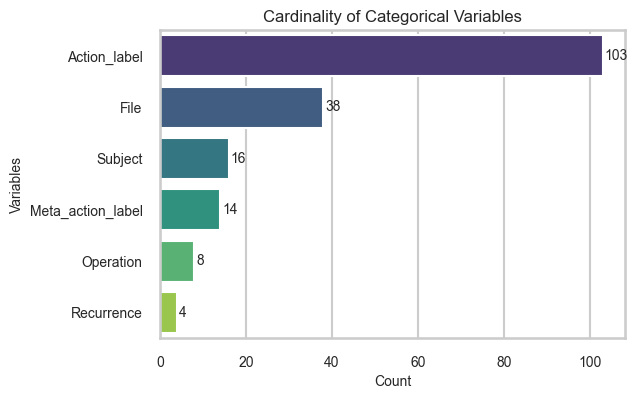

In [187]:
def plot_cardinality(df, cols):
    counts = df[cols].nunique().sort_values(ascending=False)
    plt.figure(figsize=(6, 4))
    sns.barplot(x=counts.values, y=counts.index, palette='viridis')
    
    for i, v in enumerate(counts.values):
        plt.text(v + 0.5, i, str(v), va='center', fontsize=10)

    plt.title('Cardinality of Categorical Variables')
    plt.xlabel('Count')
    plt.ylabel('Variables')
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.show()

plot_cardinality(df, cat_cols)

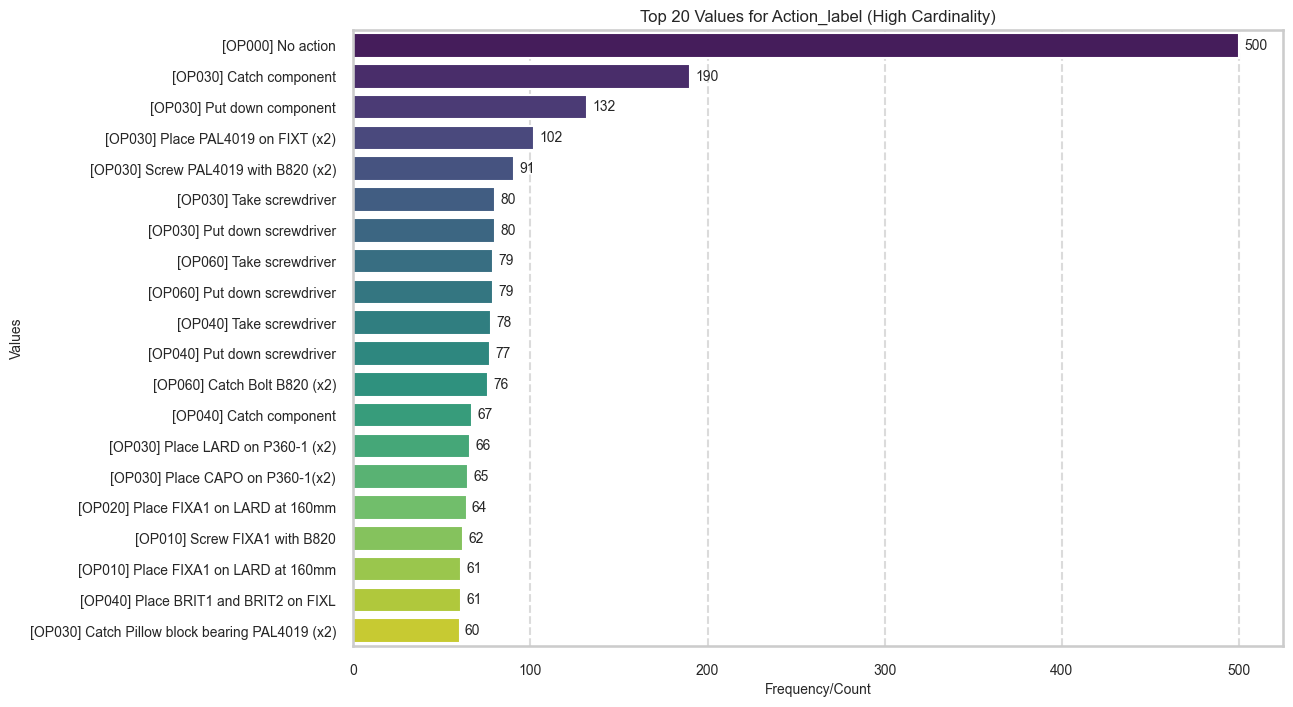

In [188]:
def plot_high_cardinality(df, column, top_n=20):
    counts = df[column].value_counts().head(top_n)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x=counts.values, 
        y=counts.index, 
        palette='viridis'
    )
    
    for i, v in enumerate(counts.values):
        plt.text(v + 3, i, f'{v:,}', va='center', fontsize=10)

    plt.title(f'Top {top_n} Values for {column} (High Cardinality)', fontsize=12)
    plt.xlabel('Frequency/Count')
    plt.ylabel('Values')
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

plot_high_cardinality(df, 'Action_label', top_n=20)

In [189]:
def calculate_imbalance_ratio(df, target_col):
    counts = df[target_col].value_counts()
    
    maj_class = counts.index[0]
    min_class = counts.index[-1]
    maj_count = counts.values[0]
    min_count = counts.values[-1]
    
    ratio = maj_count / min_count
    
    print(f'Analysis of Classes Balance: {target_col}')
    print(f'- Major Class: {maj_class} ({maj_count:,} records)')
    print(f'- Minor Class: {min_class} ({min_count:,} recods)')
    print(f'- Ratio: {ratio:.2f} : 1')
    
    if ratio > 10:
        print(f'\nResut: High Imbalance Detected')
    elif ratio > 3:
        print(f'\nResult: Moderate Imbalance Detected')
    else:
        print(f'\nResult: Balanced Dataset')
        
    return ratio

imbalance_ratio = calculate_imbalance_ratio(df, TARGET_VARIABLE)

Analysis of Classes Balance: Meta_action_label
- Major Class: Assemble system (1,378 records)
- Minor Class: Take subsystem (39 recods)
- Ratio: 35.33 : 1

Resut: High Imbalance Detected


## 4. Time Trends

In [190]:
time_cols = [col for col in num_cols if 'sec' in col.lower()]

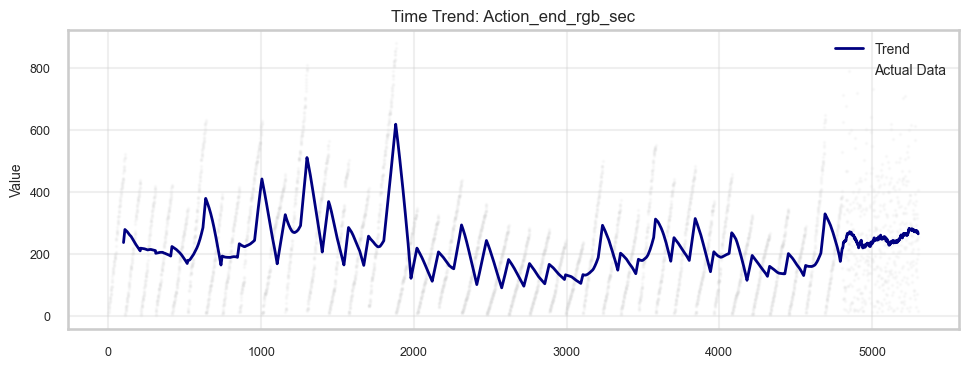

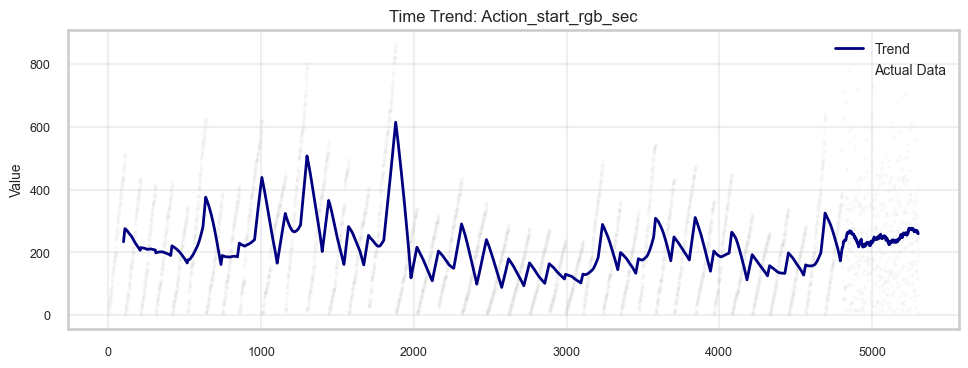

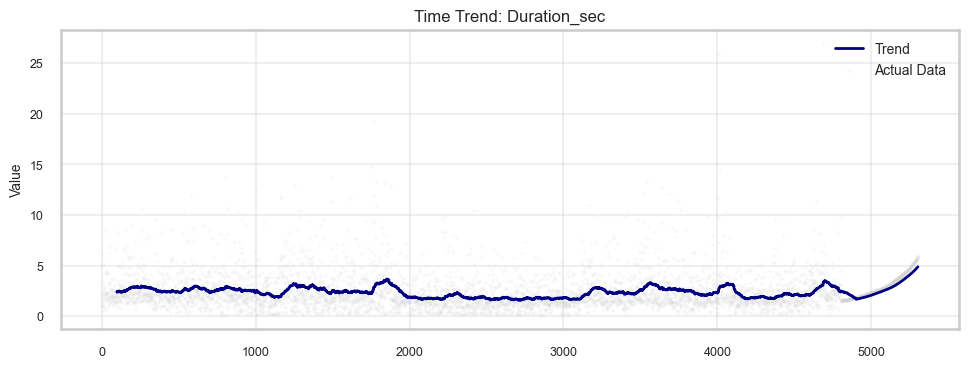

In [191]:
def plot_time_trends(df, cols, window=100):
    for col_name in cols:
        plt.figure(figsize=(10, 4))
        
        df[col_name].rolling(window=window).mean().plot(
            color='navy', 
            label=f'Trend',
            linewidth=2
        )
        
        plt.scatter(df.index, df[col_name], color='lightgray', alpha=0.1, s=1, label='Actual Data')

        plt.title(f'Time Trend: {col_name}')
        plt.ylabel('Value')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.xticks(fontsize=9)
        plt.yticks(fontsize=9)
        plt.tight_layout()
        plt.show()

plot_time_trends(df, time_cols)

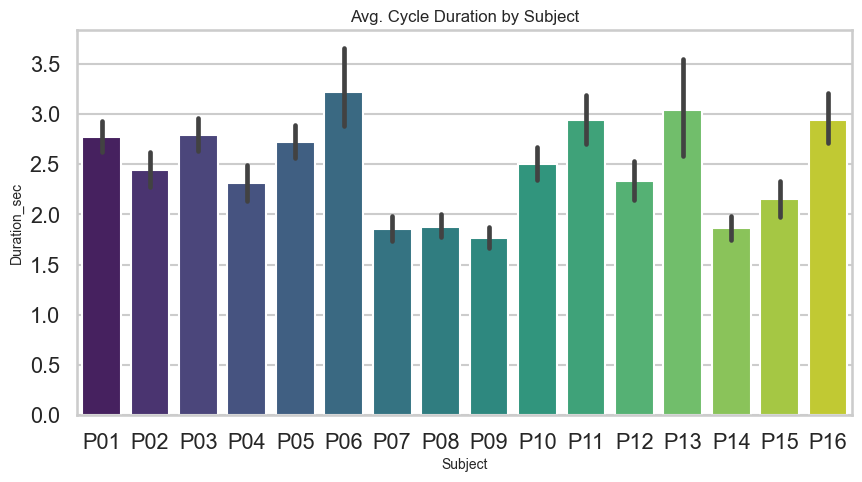

In [214]:
def plot_subject_trends(df, subjects=None):
    if subjects is None:
        subjects = df['Subject'].unique()

    plt.figure(figsize=(10, 5))
    sns.barplot(data=df[df['Subject'].isin(subjects)], 
                x='Subject', y='Duration_sec', palette='viridis')
    plt.title('Avg. Cycle Duration by Subject')
    plt.show()

plot_subject_trends(df)

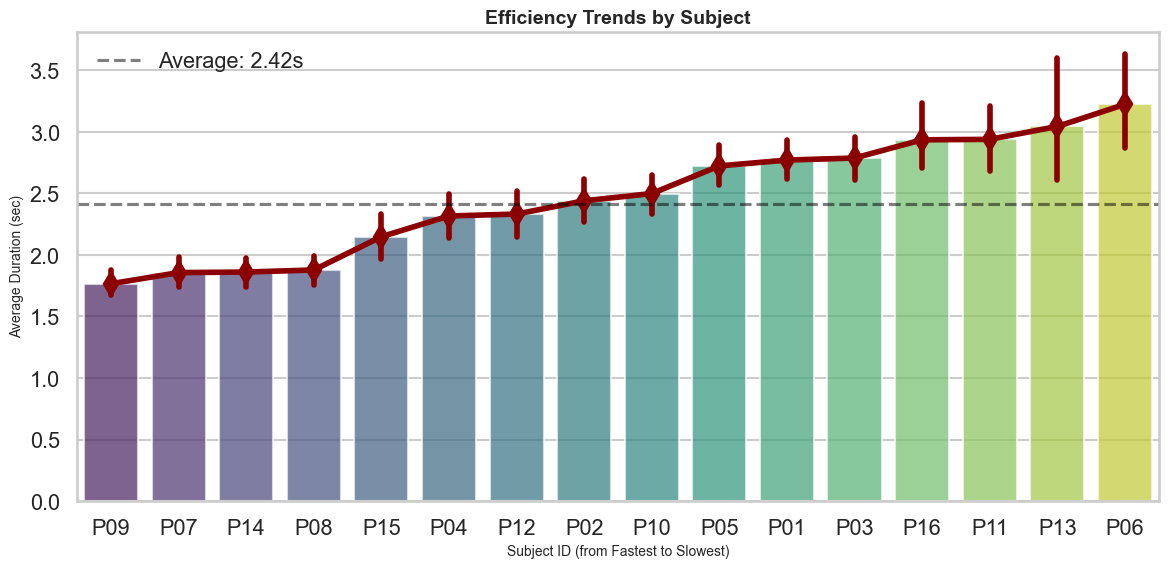

In [213]:
def plot_subject_trends_by_efficiency(df, subjects=None):
    if subjects is None:
        subjects = df['Subject'].unique()
    
    df_filtered = df[df['Subject'].isin(subjects)]
    subject_order = df_filtered.groupby('Subject')['Duration_sec'].mean().sort_values().index

    plt.figure(figsize=(12, 6))
    
    sns.barplot(
        data=df_filtered, 
        x='Subject', 
        y='Duration_sec', 
        order=subject_order, 
        palette='viridis', 
        alpha=0.7,
        errorbar=None 
    )
    
    sns.pointplot(
        data=df_filtered, 
        x='Subject', 
        y='Duration_sec', 
        order=subject_order, 
        color='darkred', 
        markers='d', 
        linestyles='-'
    )
    
    avg_global = df_filtered['Duration_sec'].mean()
    plt.axhline(avg_global, color='black', linestyle='--', alpha=0.5, label=f'Average: {avg_global:.2f}s')

    plt.title('Efficiency Trends by Subject', fontsize=14, fontweight='bold')
    plt.xlabel('Subject ID (from Fastest to Slowest)')
    plt.ylabel('Average Duration (sec)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_subject_trends_by_efficiency(df)

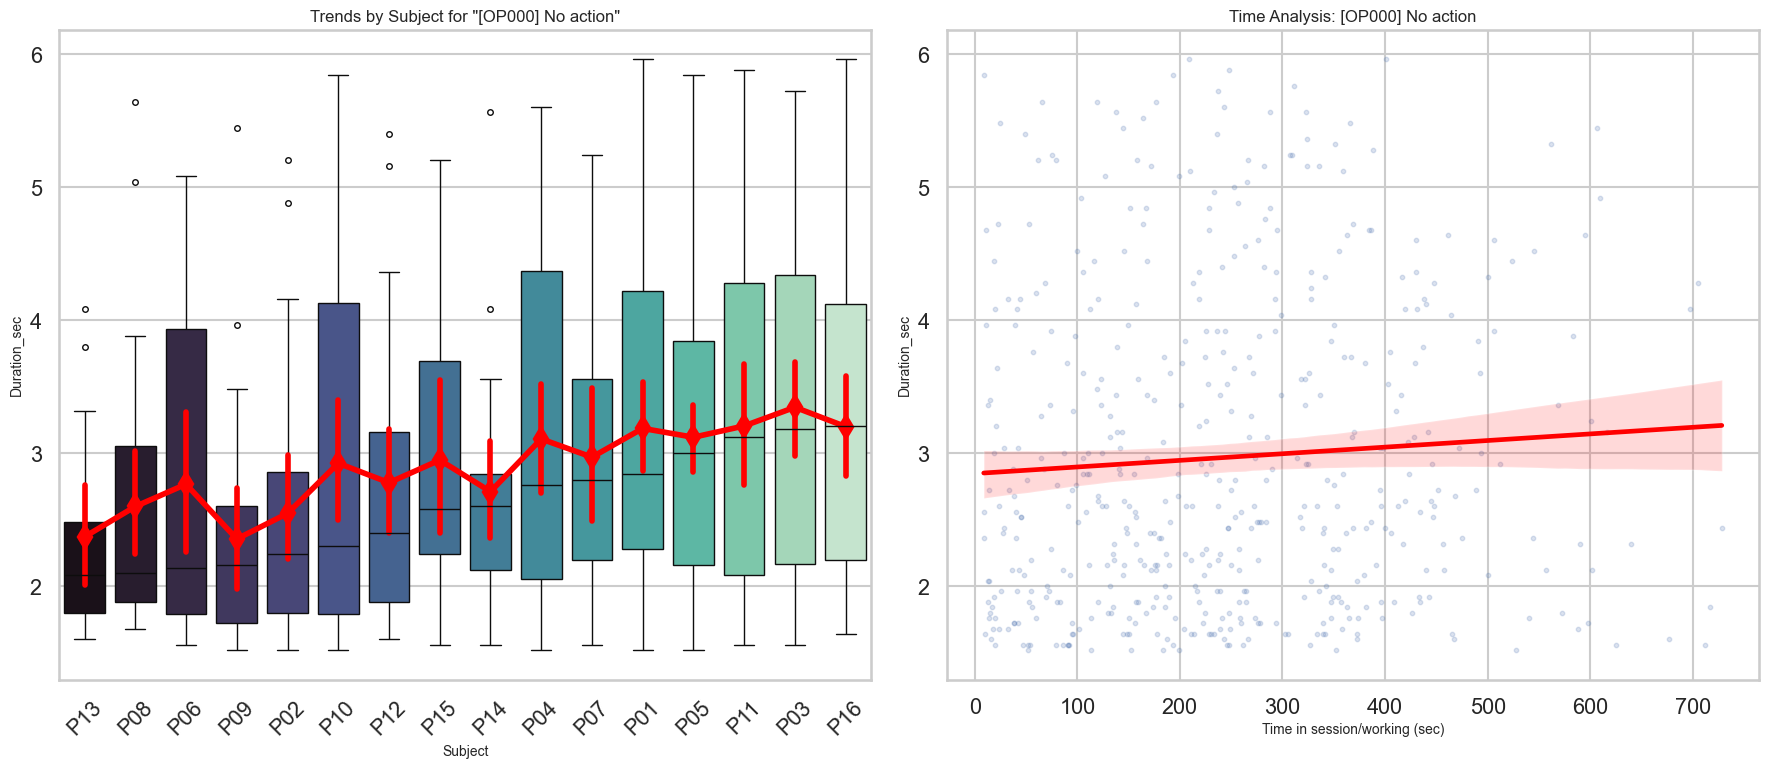

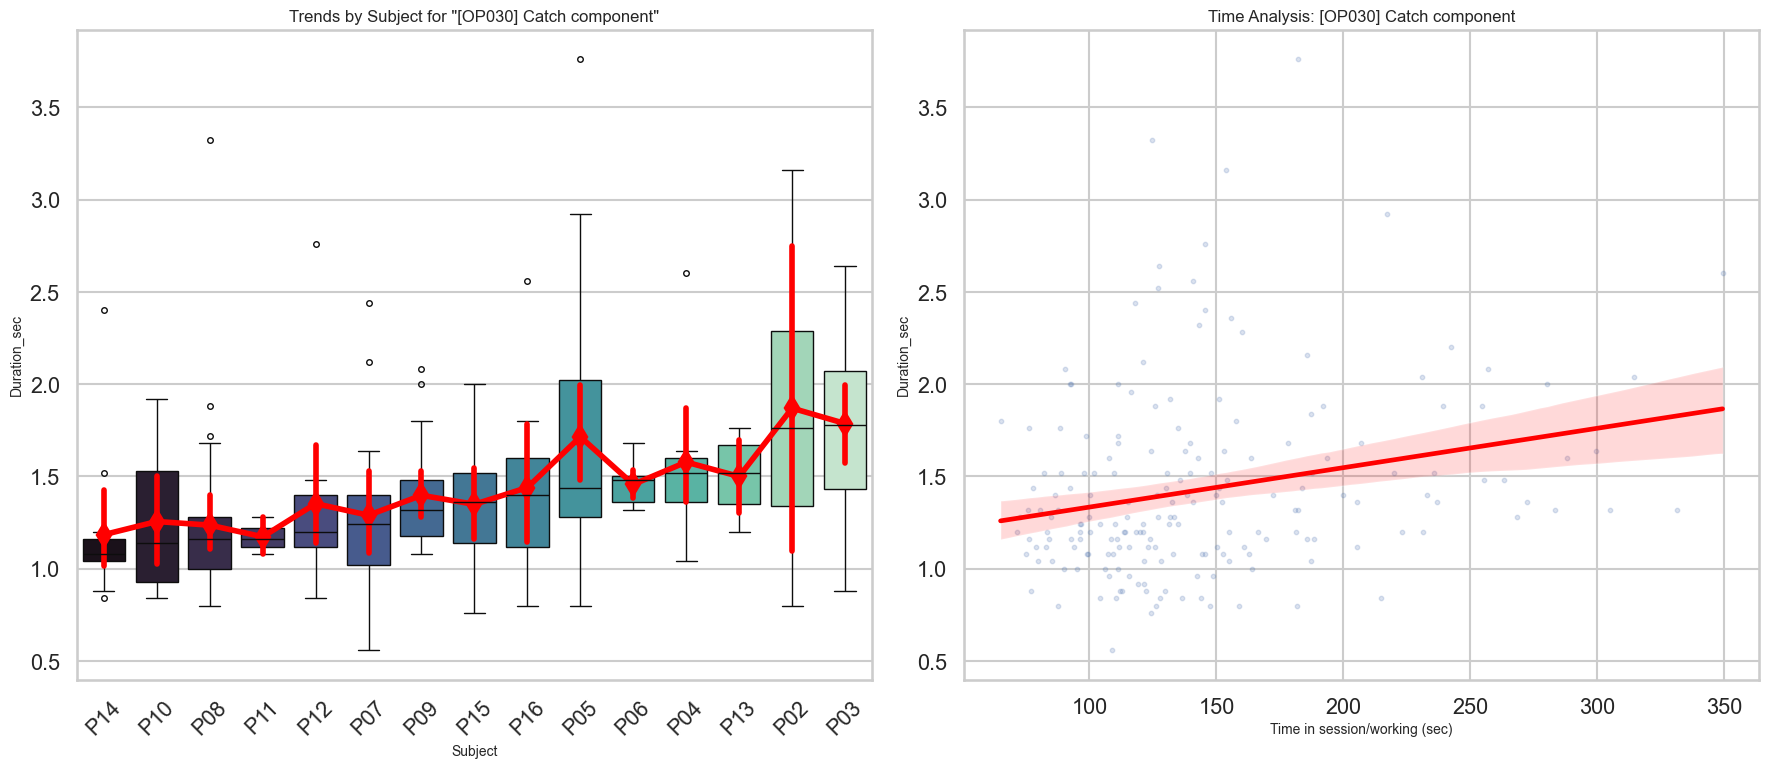

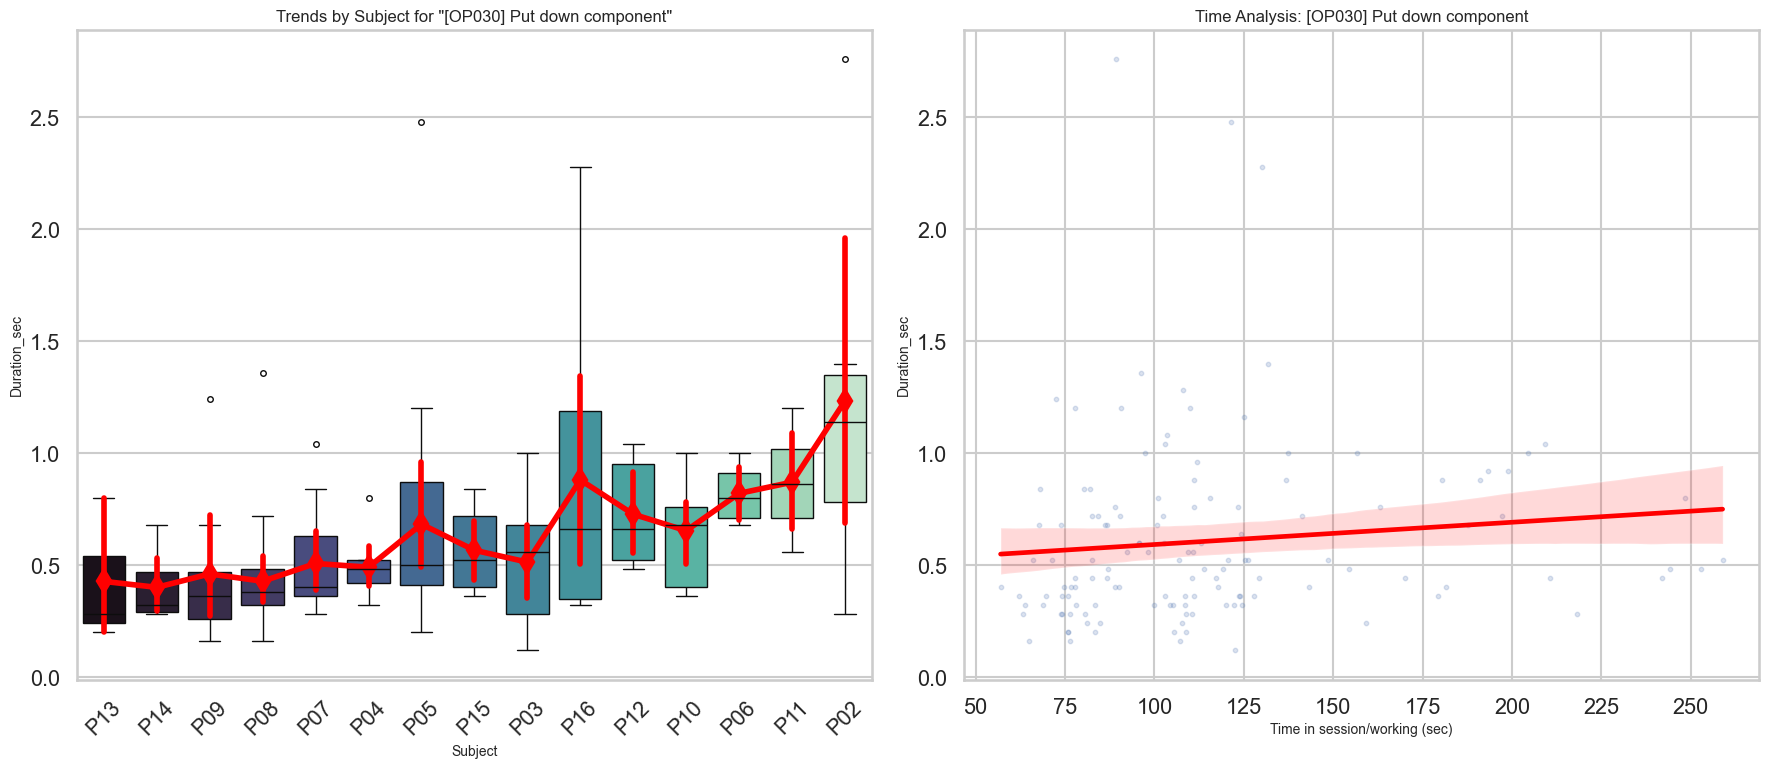

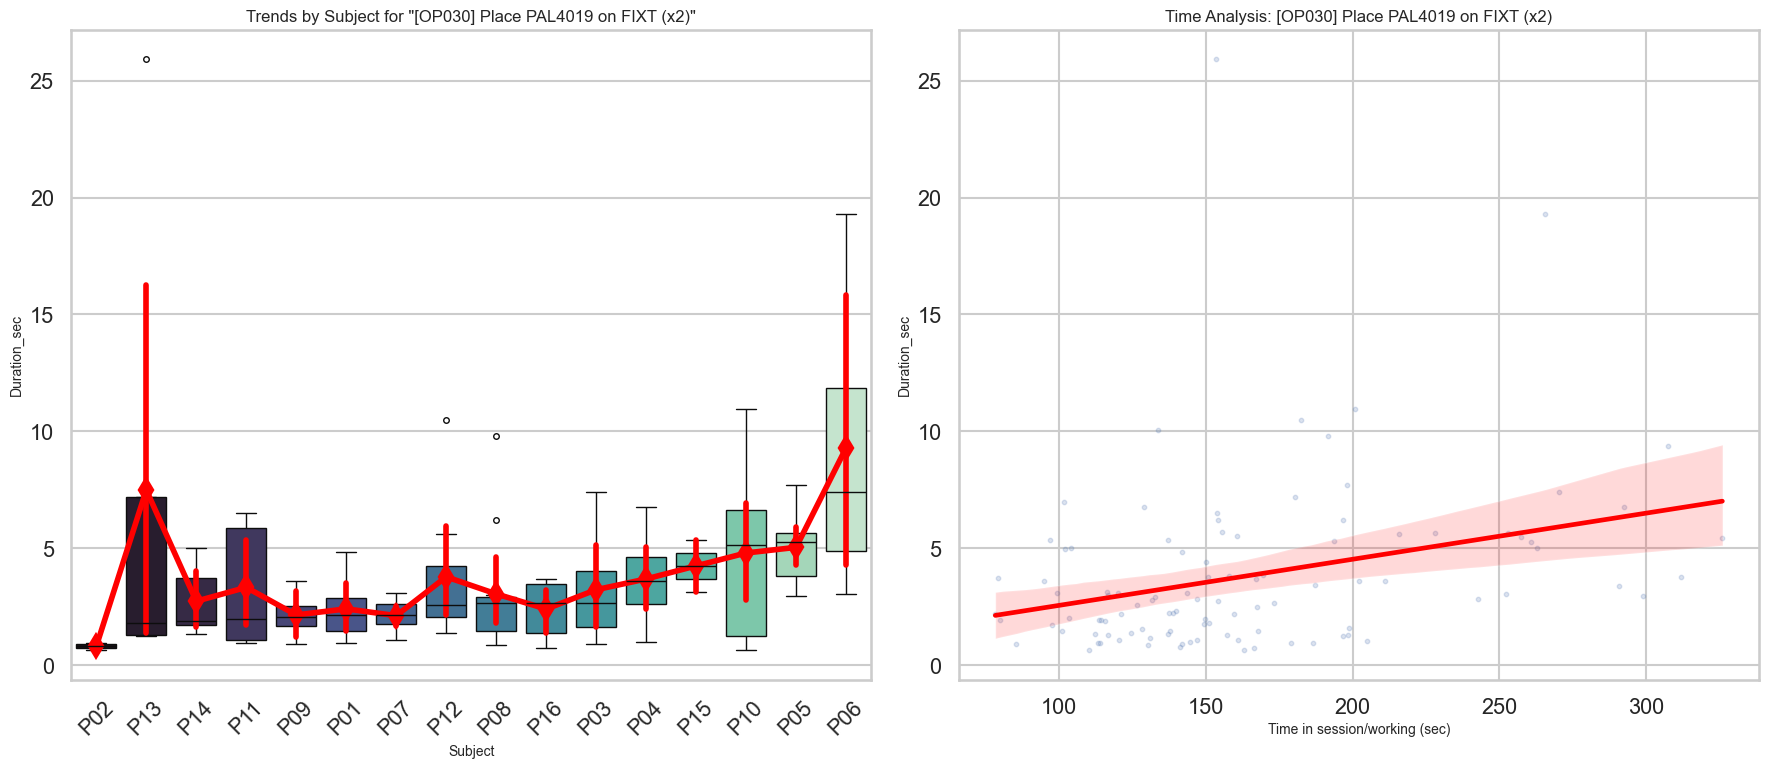

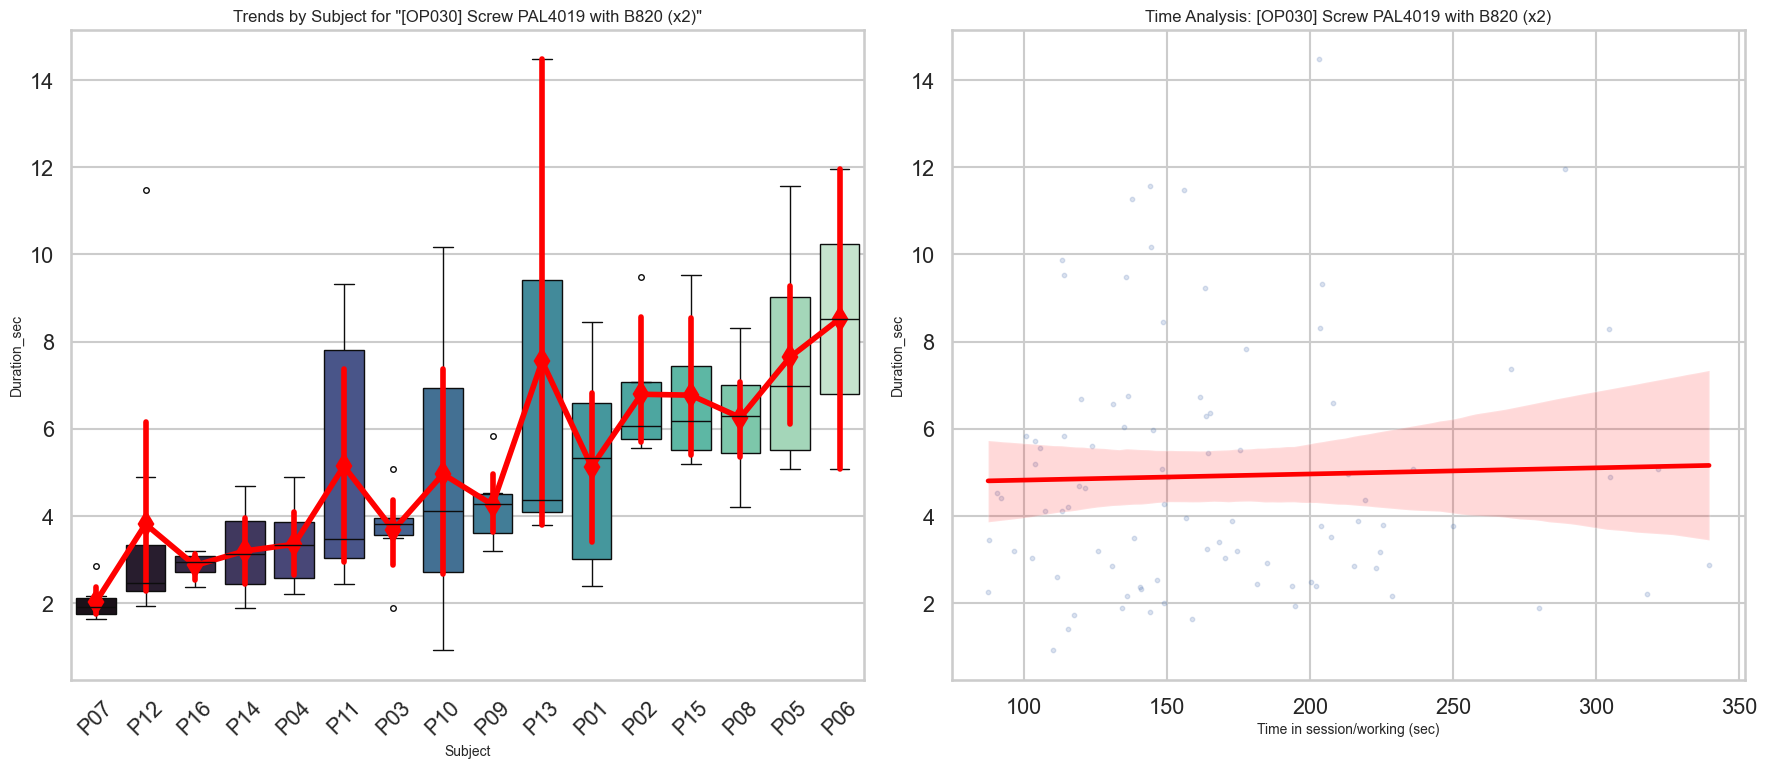

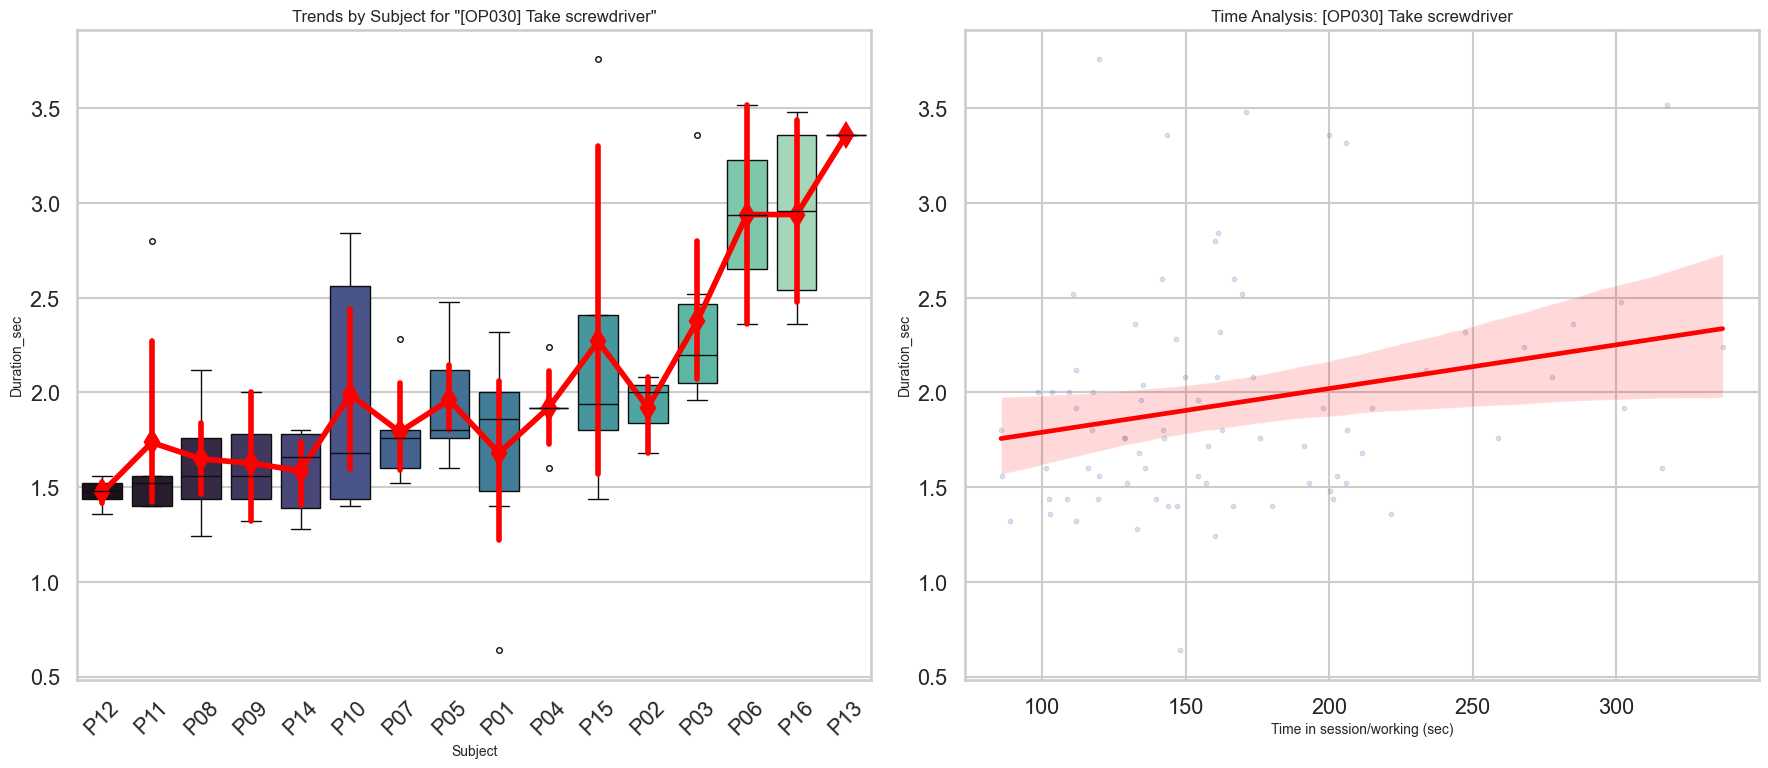

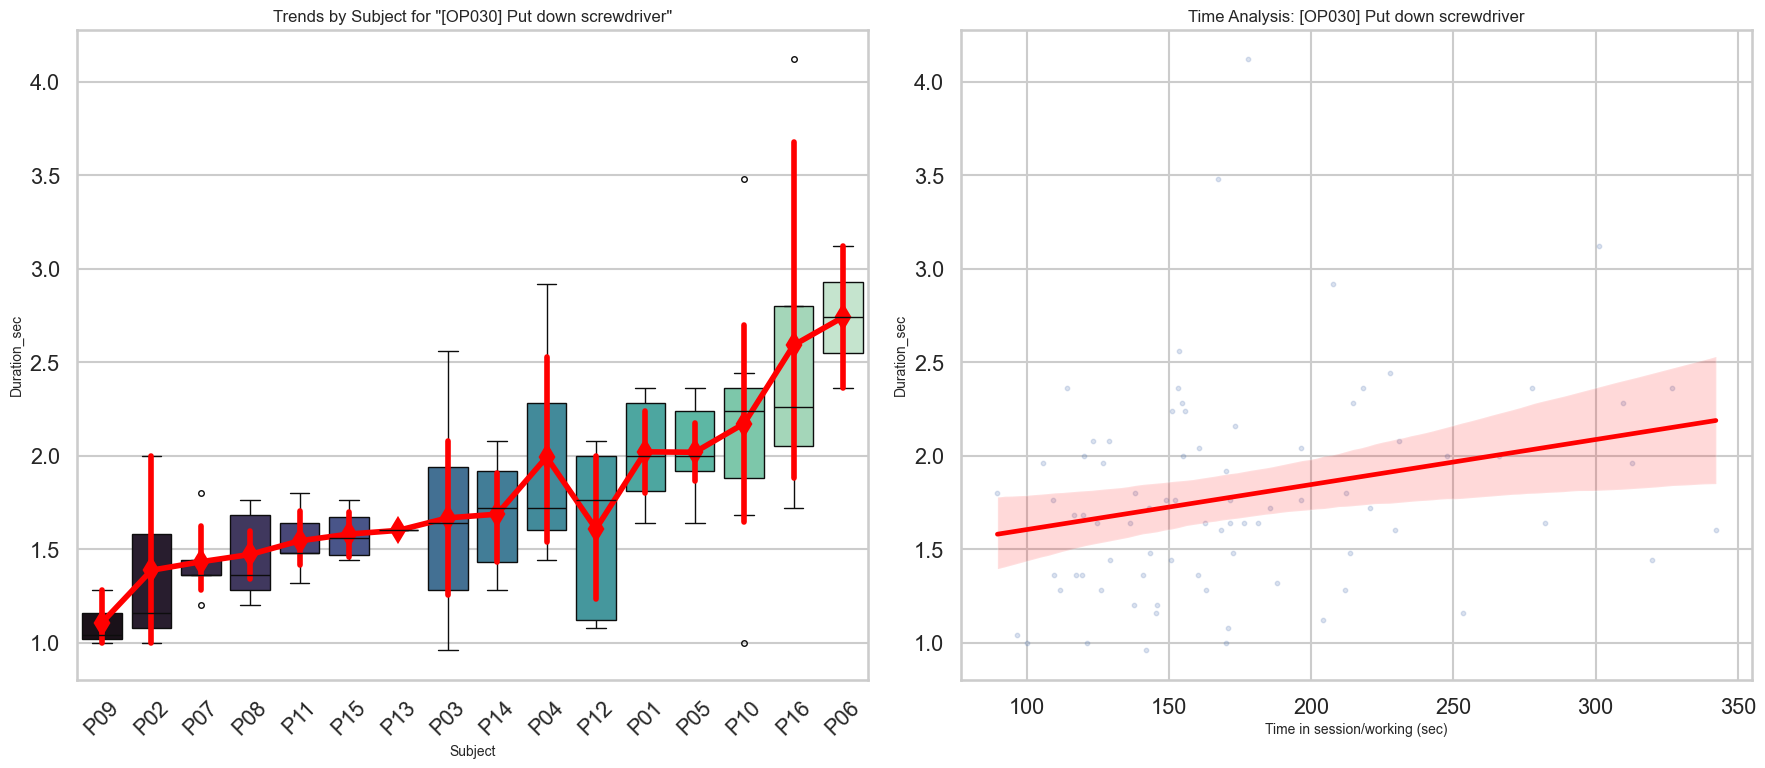

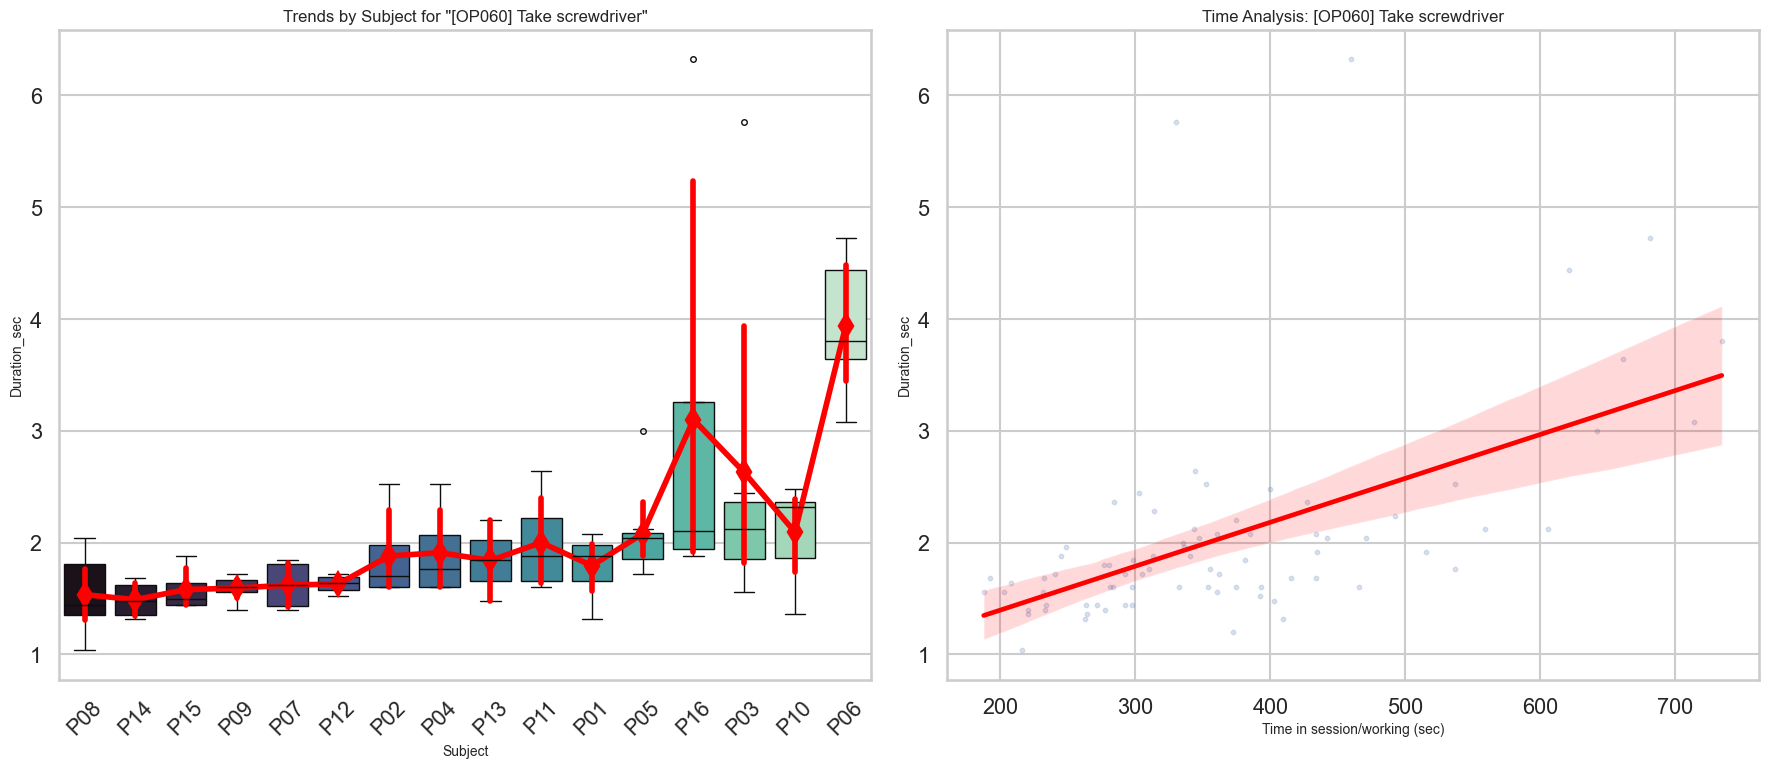

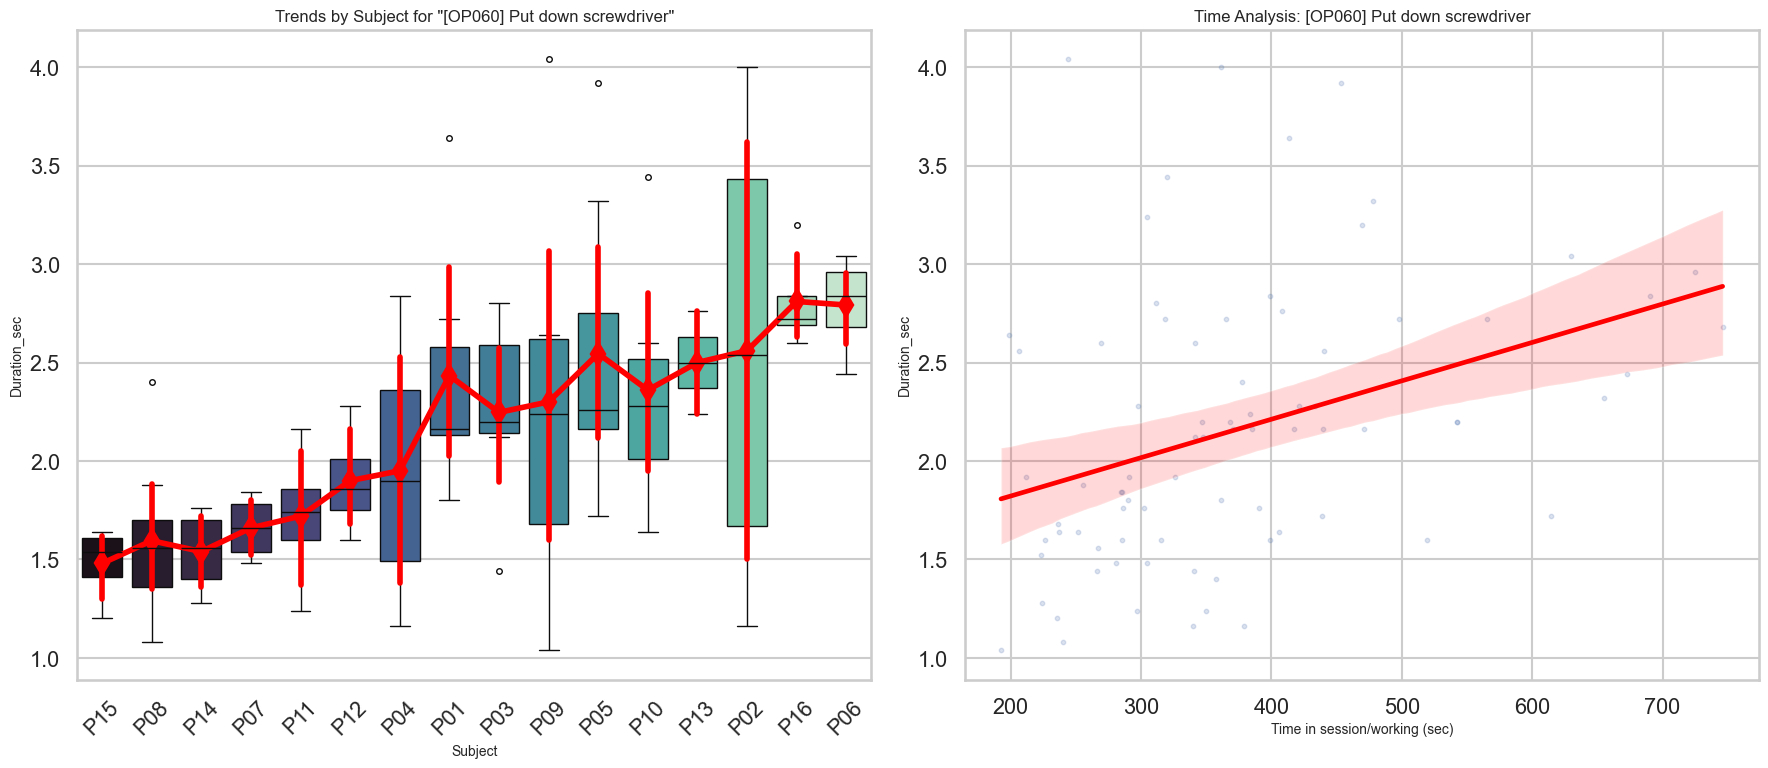

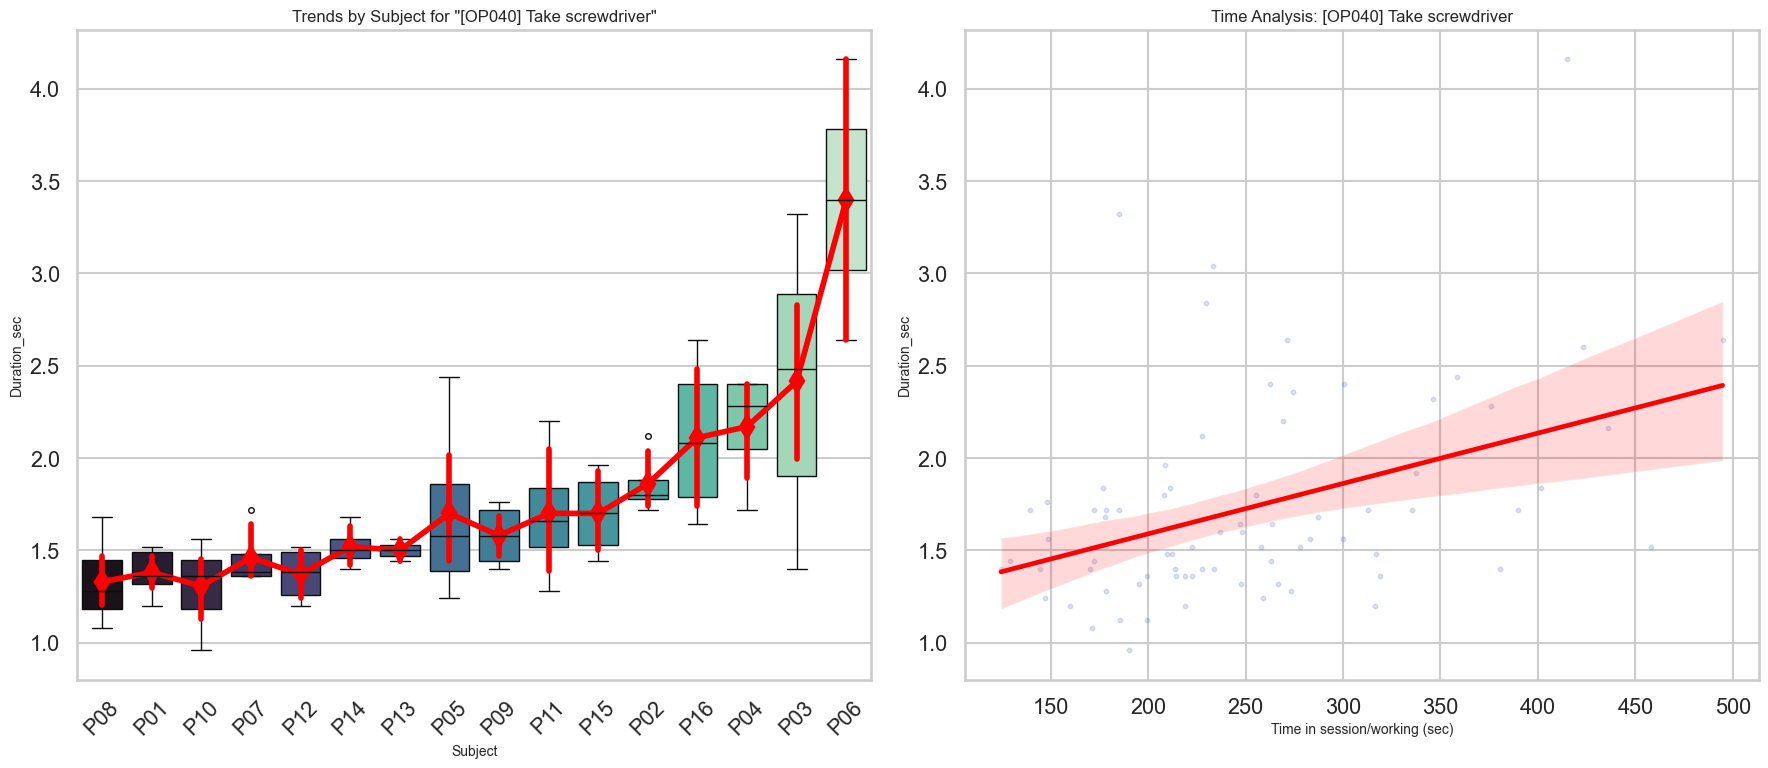

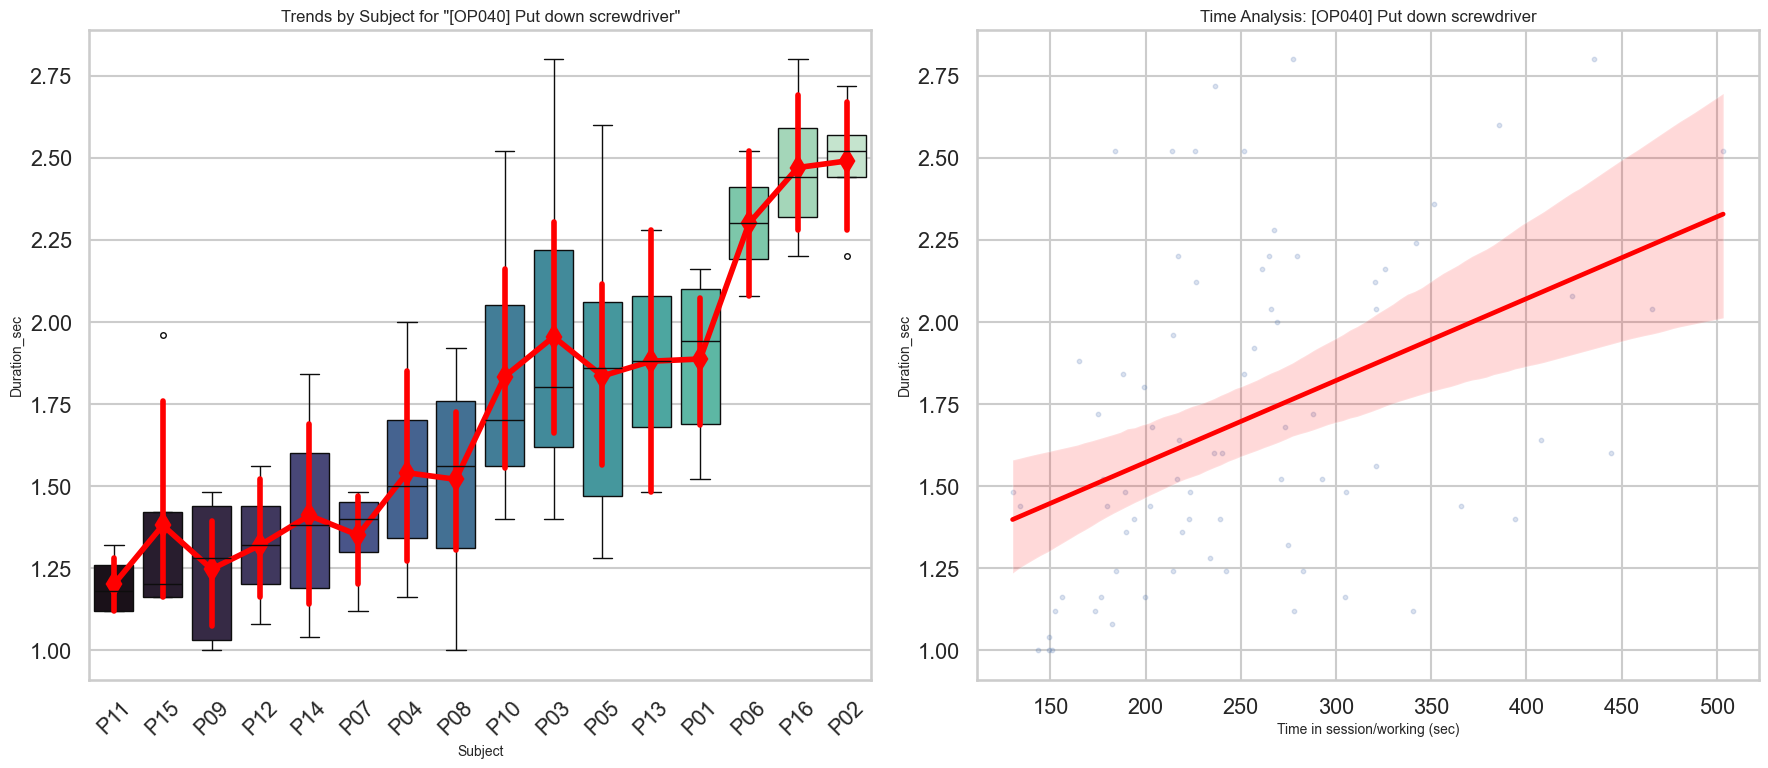

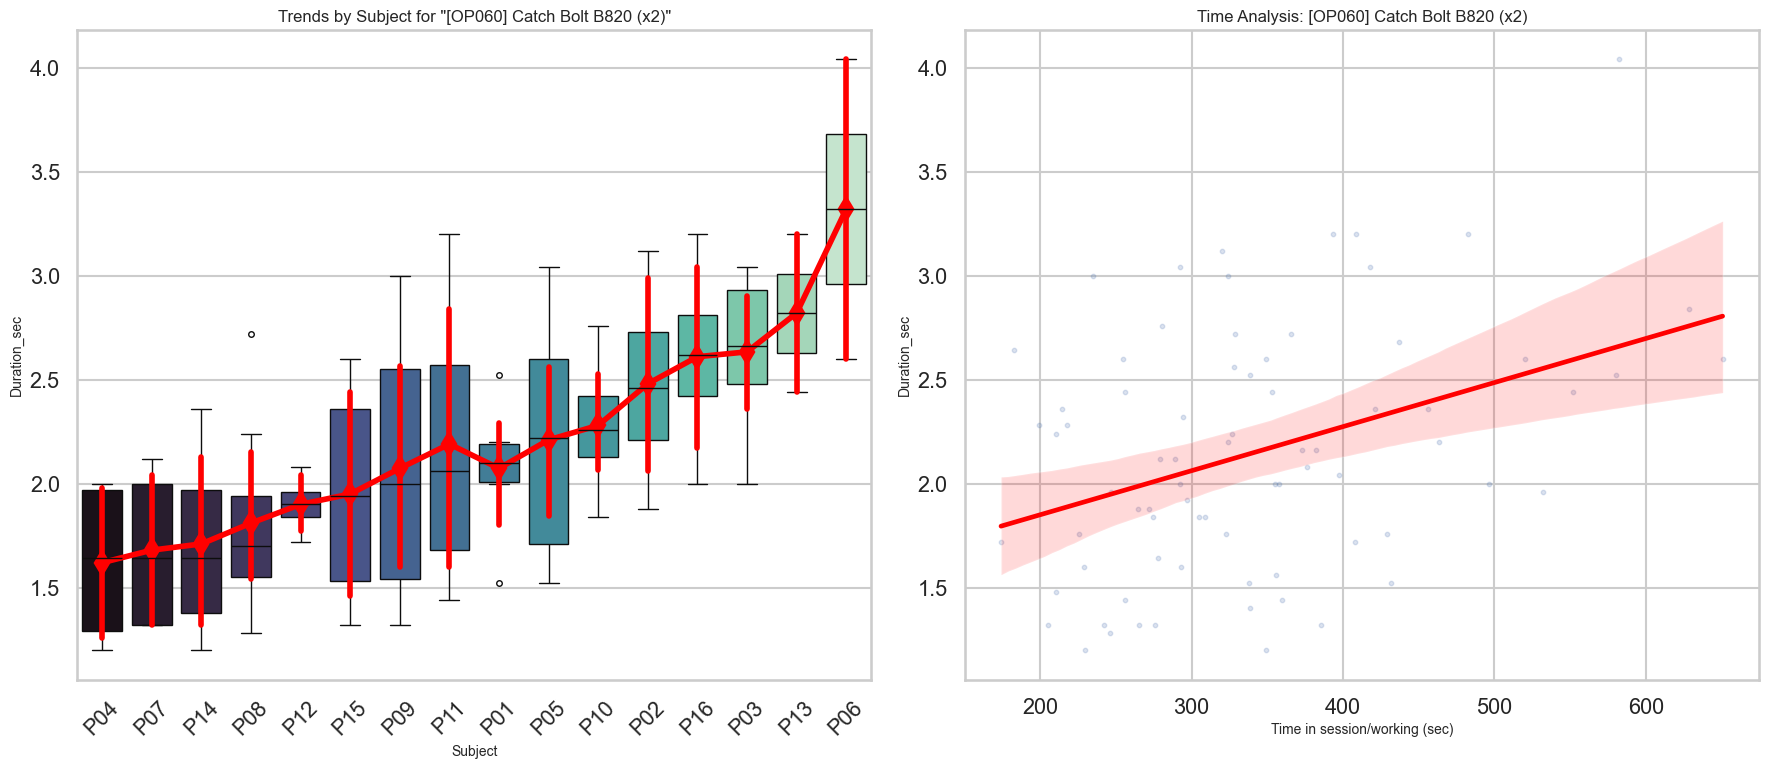

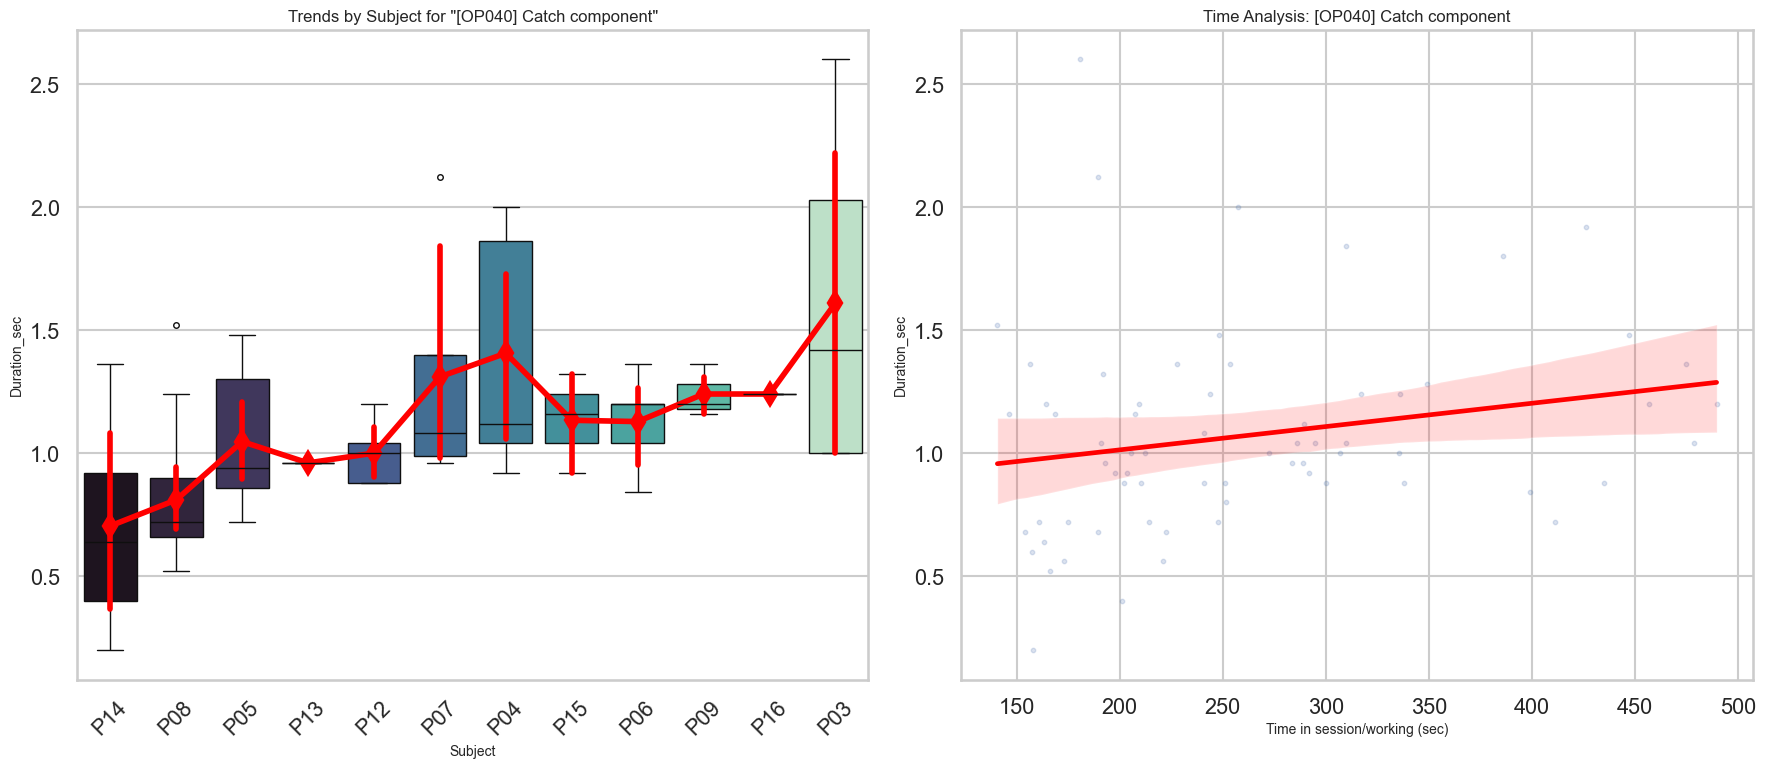

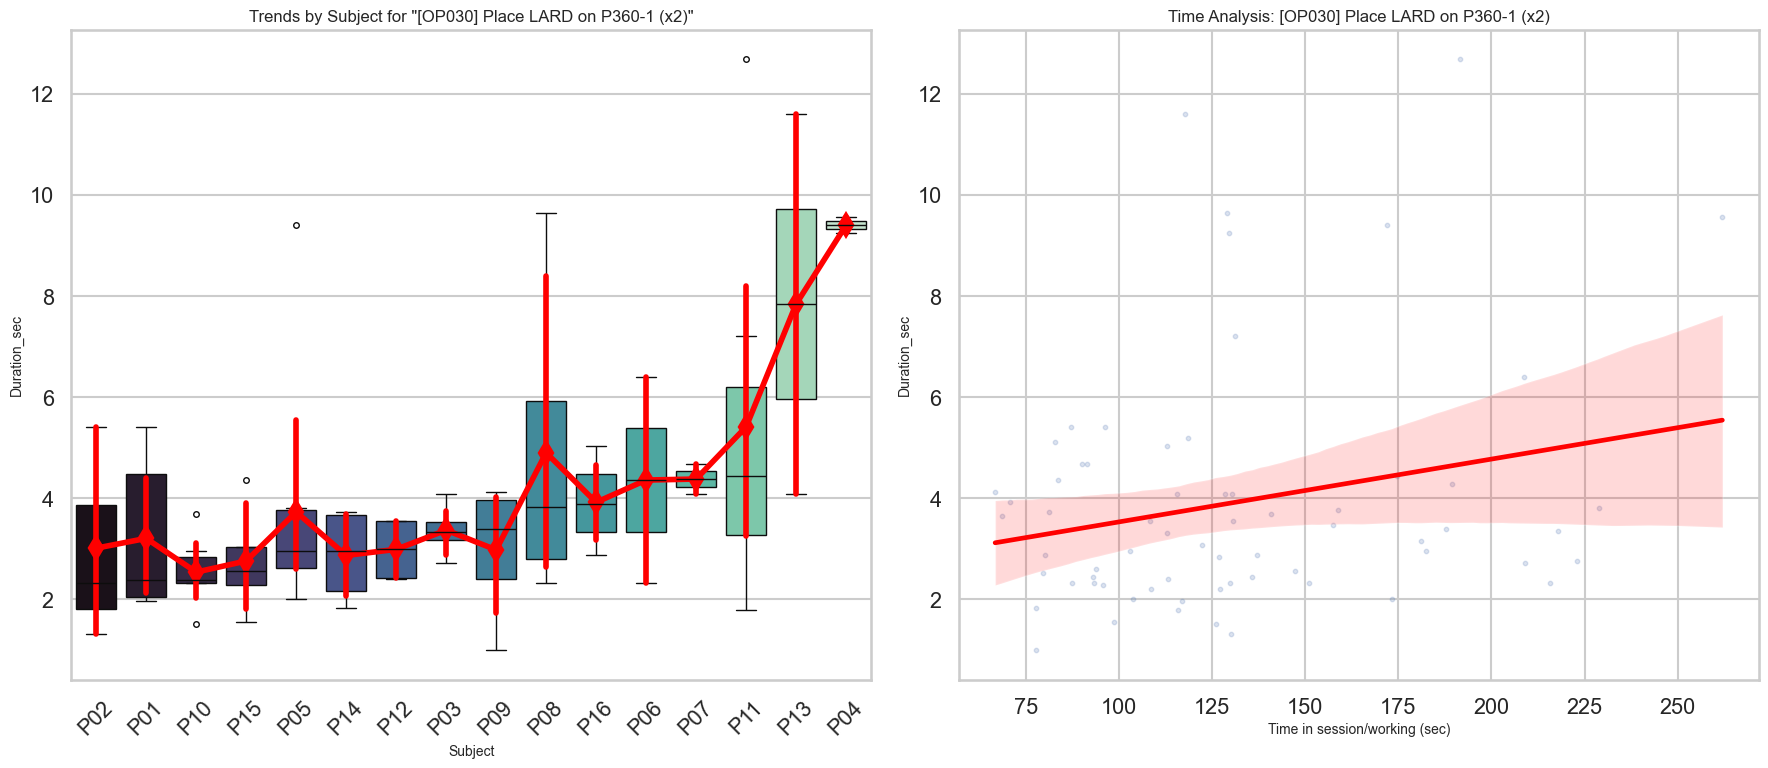

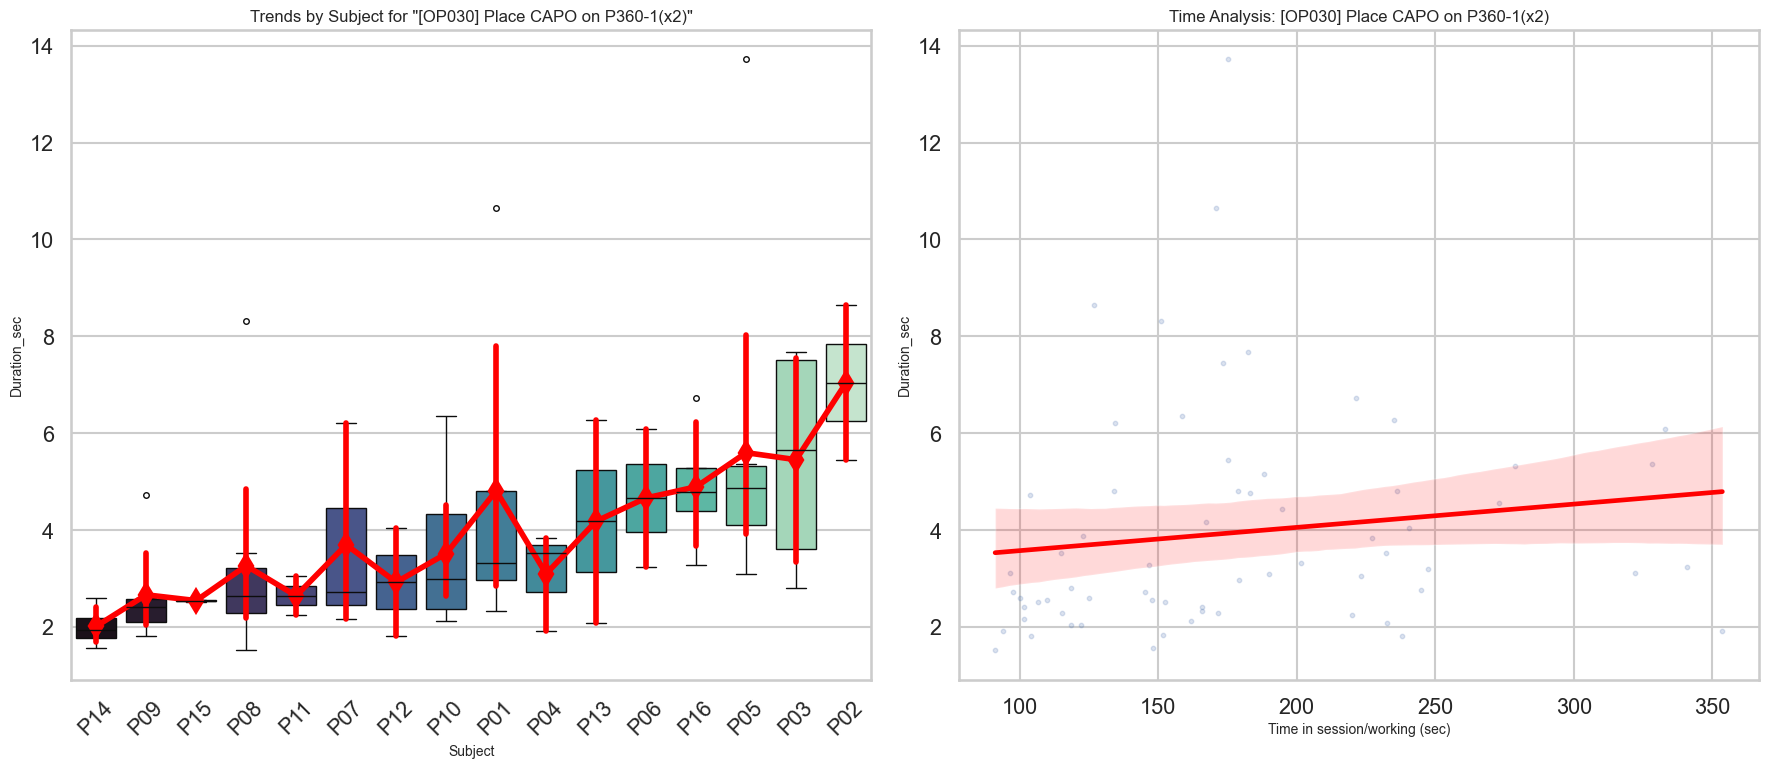

In [219]:
def analyze_action_dynamics(df, actions):
    for action in actions:
        temp_df = df[df['Action_label'] == action].copy()
        
        subject_order = temp_df.groupby('Subject')['Duration_sec'].median().sort_values().index
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
        
        sns.boxplot(
            data=temp_df, x='Subject', y='Duration_sec', 
            order=subject_order, ax=ax1, palette='mako', fliersize=4
        )

        sns.pointplot(
            data=temp_df, x='Subject', y='Duration_sec', 
            order=subject_order, ax=ax1, color='red', markers='d', linestyles='-'
        )
        ax1.set_title(f'Trends by Subject for "{action}"', fontsize=12)
        ax1.tick_params(axis='x', rotation=45)
        
        sns.regplot(
            data=temp_df, x='Action_start_rgb_sec', y='Duration_sec', 
            ax=ax2, scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'}
        )
        ax2.set_title(f'Time Analysis: {action}', fontsize=12)
        ax2.set_xlabel('Time in session/working (sec)')
        
        plt.tight_layout()
        plt.show()

top_actions = df['Action_label'].value_counts().index[:15]
analyze_action_dynamics(df, top_actions)

In [220]:
df['bvh_duration_frames'] = df['Action_end_bvh_frame'] - df['Action_start_bvh_frame']
df['rgb_duration_frames'] = df['Action_end_rgb_frame'] - df['Action_start_rgb_frame']

df['calculated_fps'] = df['rgb_duration_frames'] / df['Duration_sec'].replace(0, np.nan)

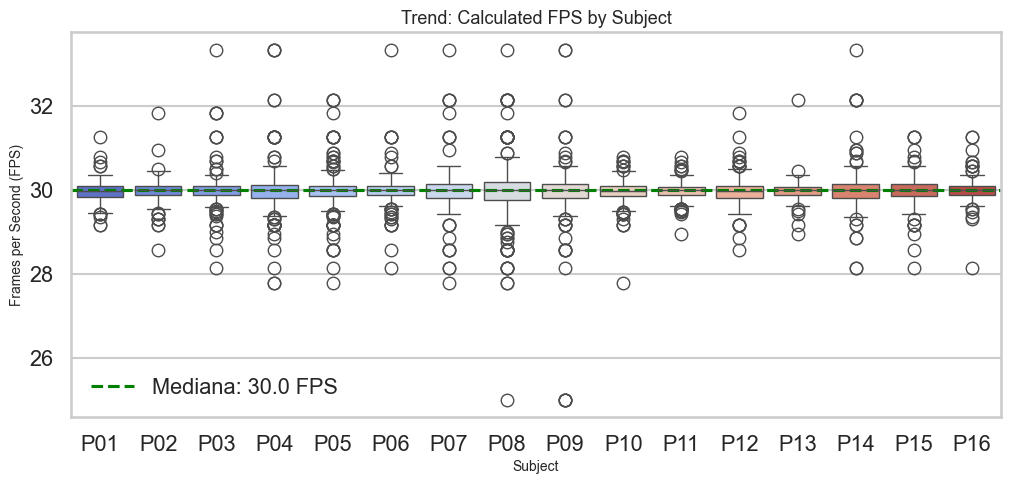

In [223]:
def plot_fps(df):
    plt.figure(figsize=(12, 5))
    
    sns.boxplot(data=df, x='Subject', y='calculated_fps', palette='coolwarm')
    
    expected_fps = df['calculated_fps'].median()
    plt.axhline(expected_fps, color='green', linestyle='--', label=f'Mediana: {expected_fps:.1f} FPS')
    
    plt.title('Trend: Calculated FPS by Subject', fontsize=13)
    plt.ylabel('Frames per Second (FPS)')
    plt.legend()
    plt.show()

plot_fps(df)

## 5. Bi-Variant Analysis

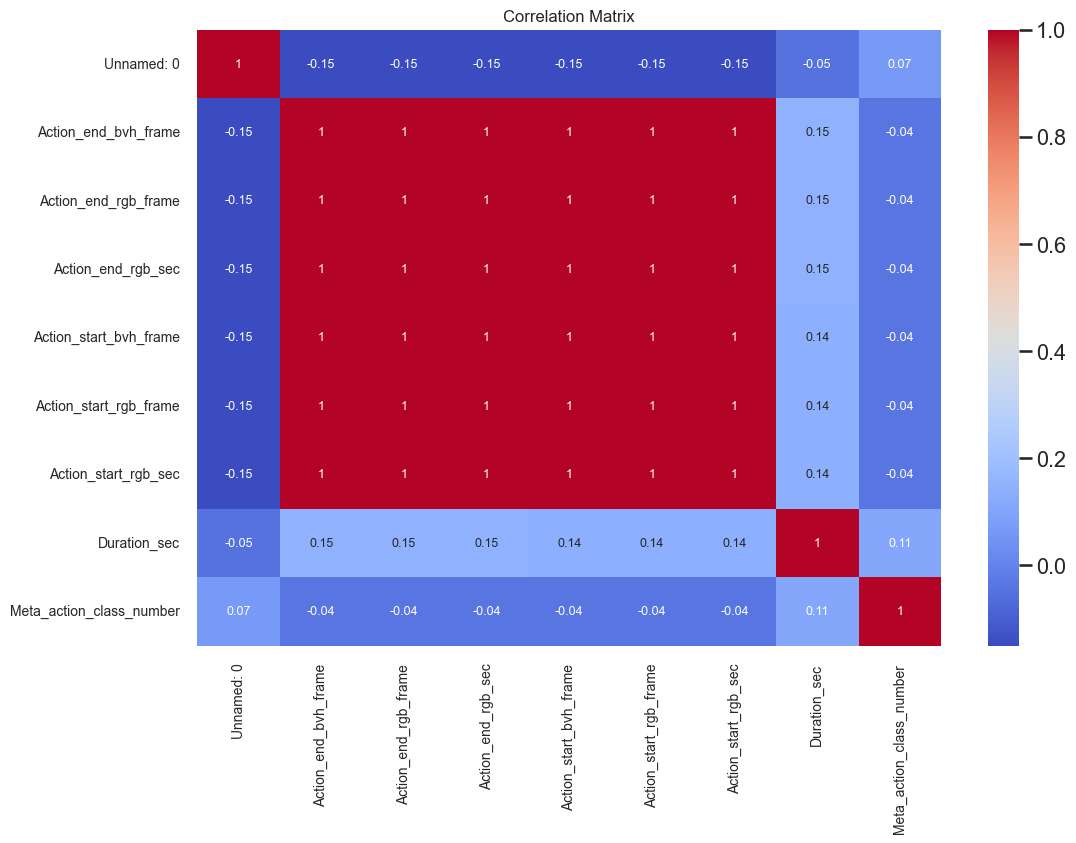

In [192]:
plt.figure(figsize = (12, 8))
sns.heatmap(round(df.corr(numeric_only=True),2), cmap="coolwarm", annot=True,annot_kws={"size": 9})    
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title('Correlation Matrix')
plt.show()

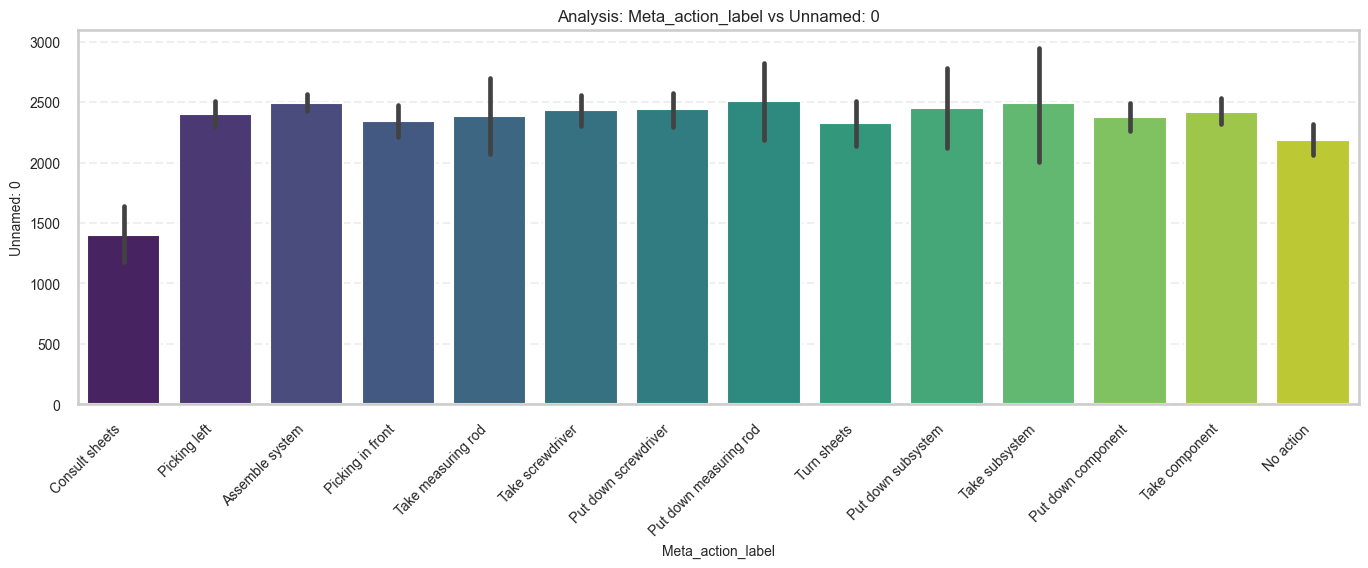

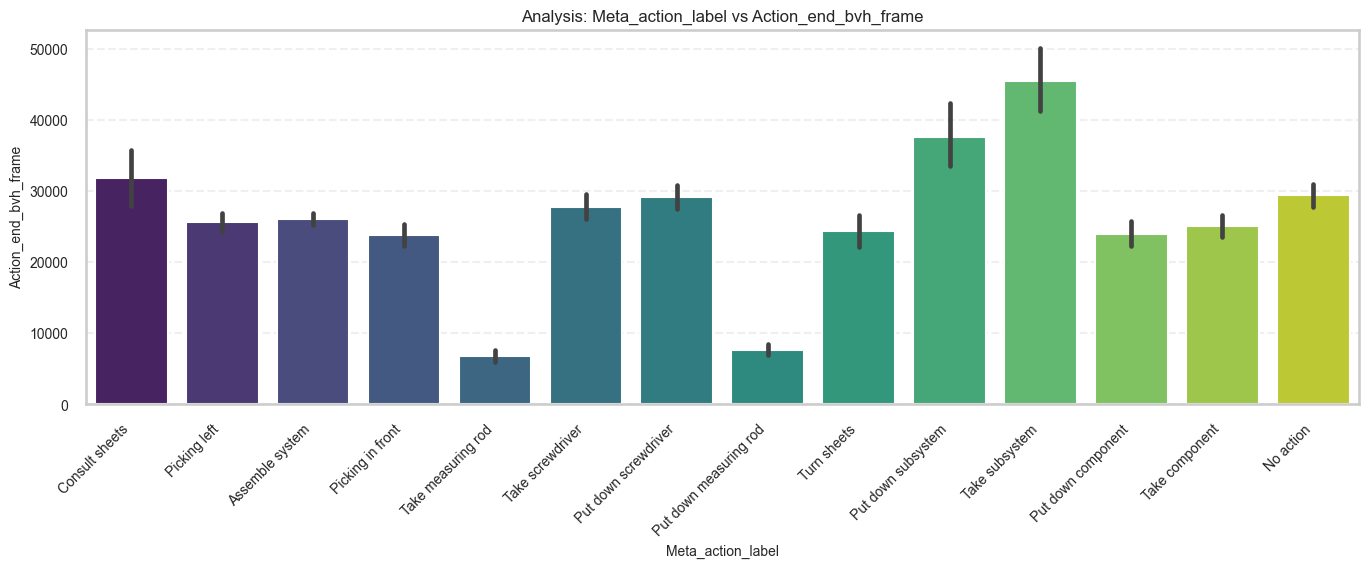

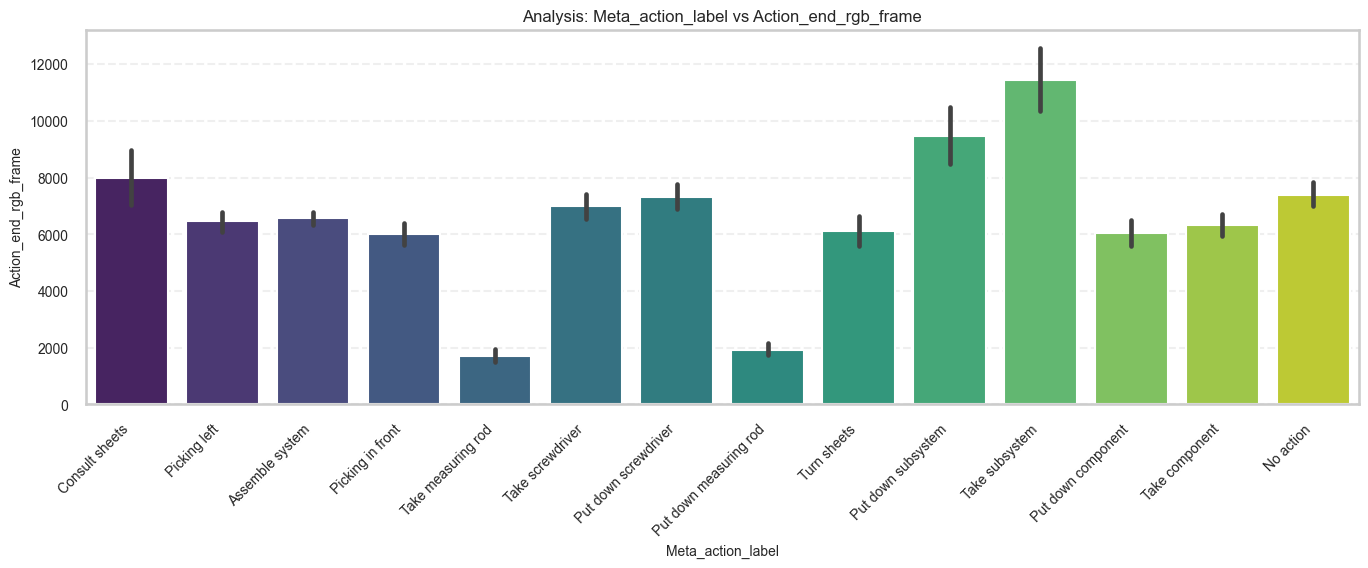

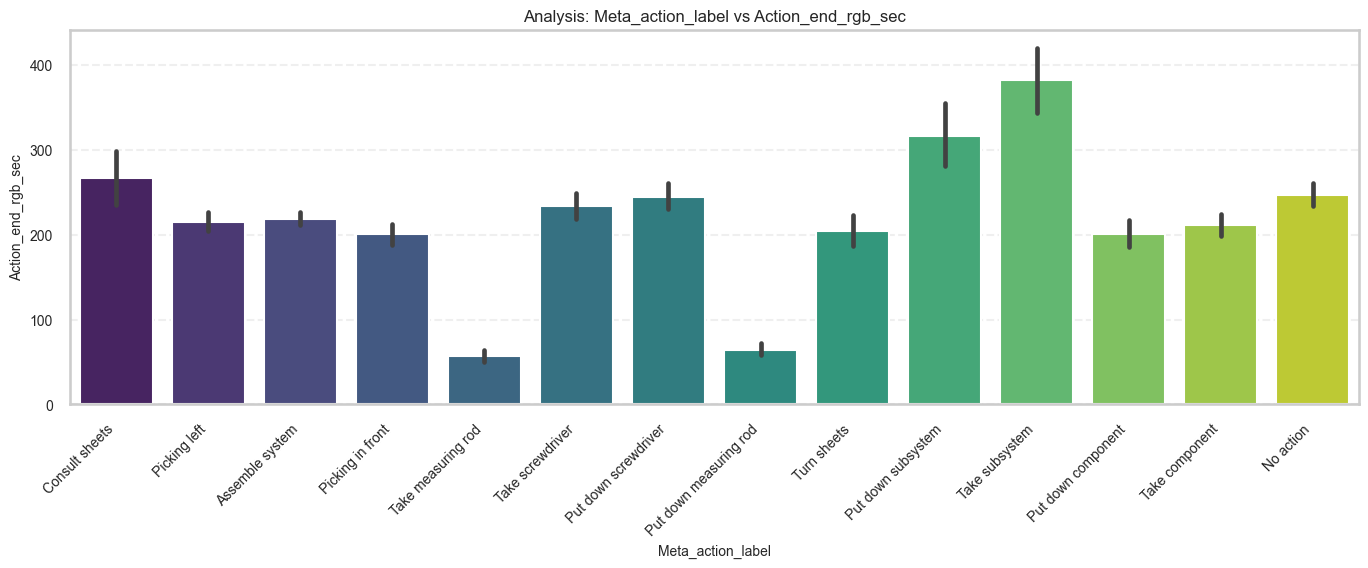

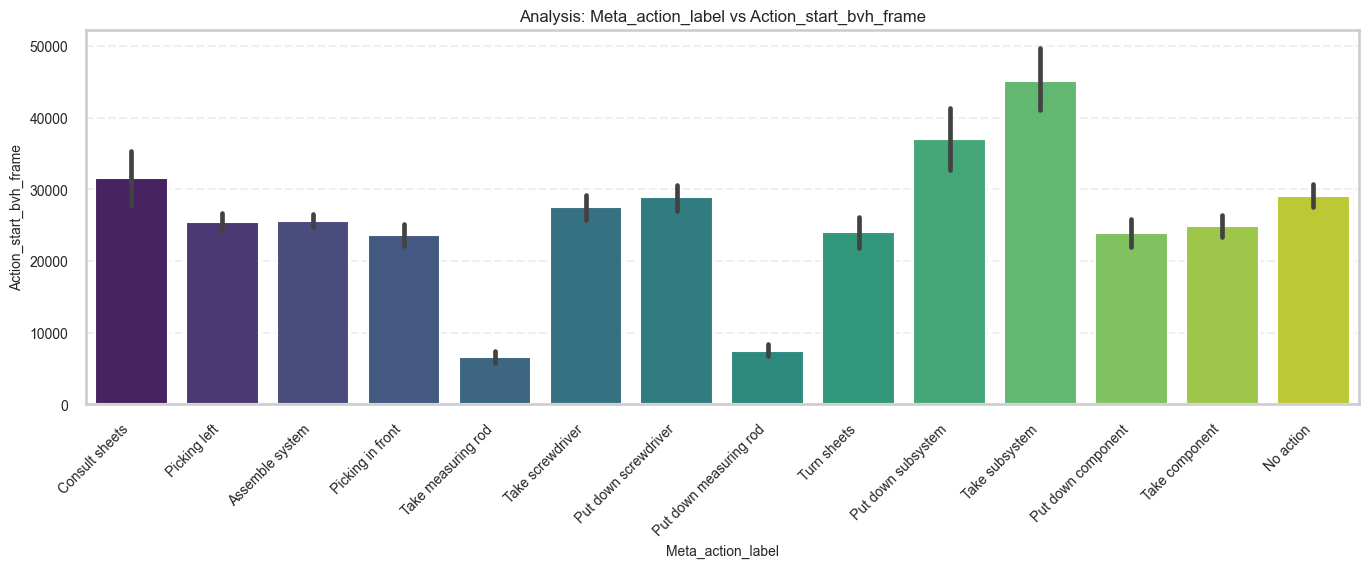

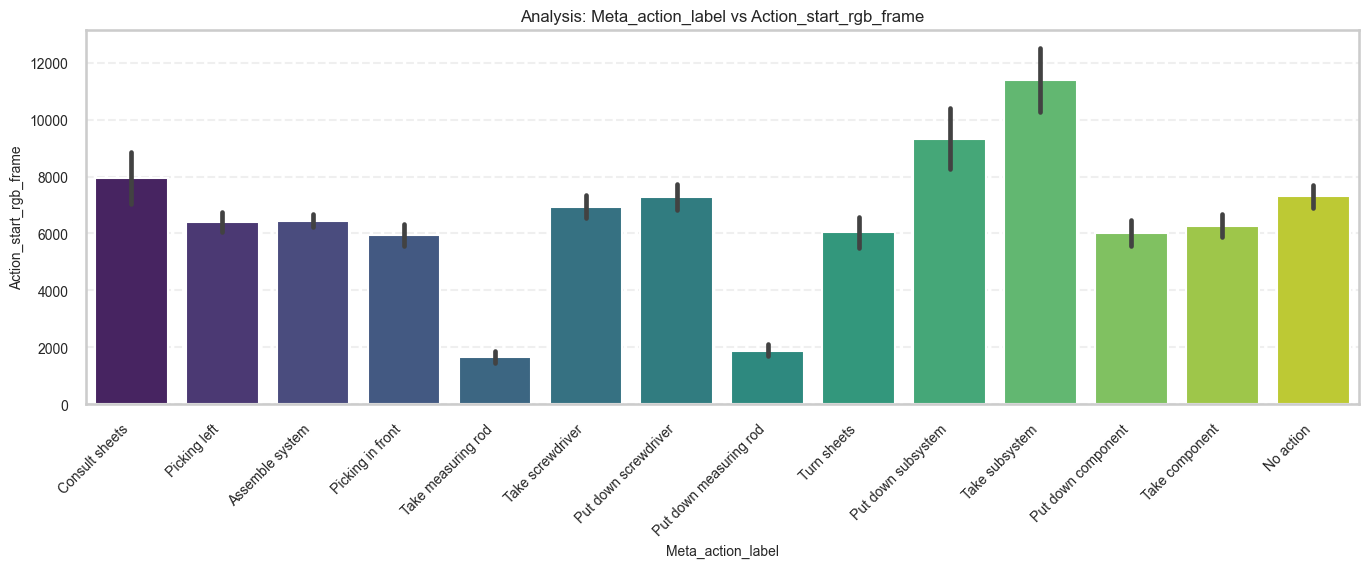

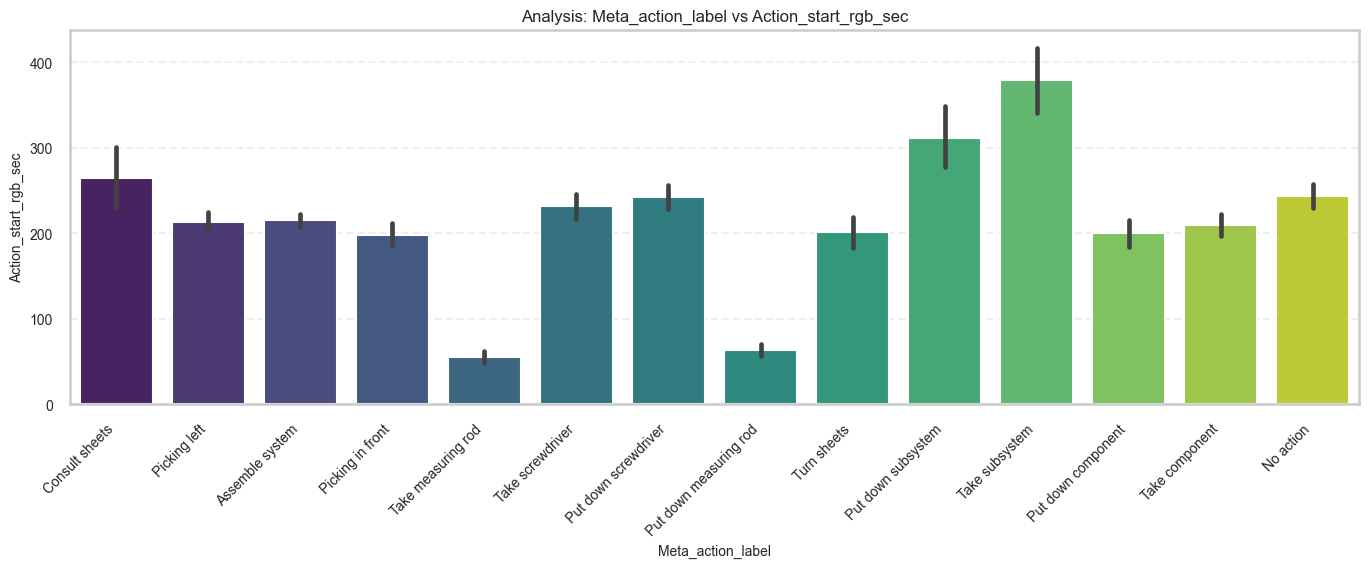

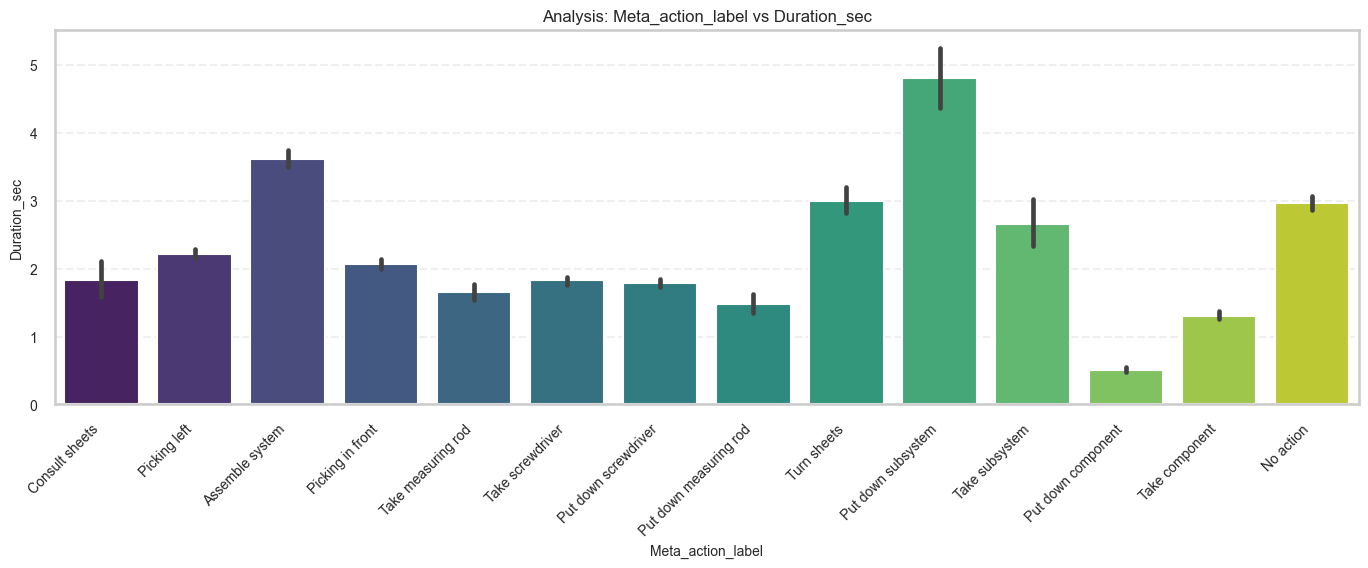

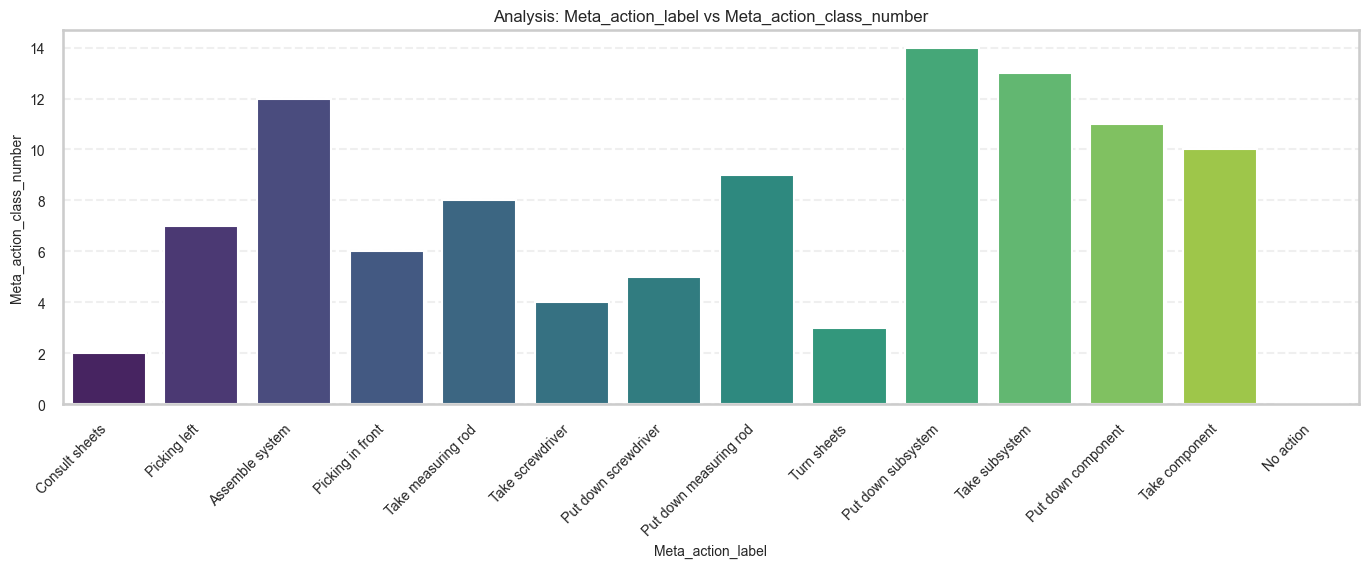

In [193]:
def plot_multivariate_analysis(df, target_col, features, type='auto'):
    for col in features:
        if col == target_col: continue
        
        plt.figure(figsize=(14, 6))
        
        if df[col].dtype in ['int64', 'float64']:
            sns.barplot(
                data=df, 
                x=target_col, 
                y=col, 
                palette='viridis', 
                estimator=np.mean,
                errorbar=('ci', 95) 
            )
            plt.title(f'Analysis: {target_col} vs {col}')
            plt.ylabel(f'{col}')
            
        else:
            top_cats = df[col].value_counts().index[:10]
            sns.countplot(
                data=df[df[col].isin(top_cats)], 
                x=target_col, 
                hue=col, 
                palette='viridis'
            )
            plt.title(f'Distribution of {col} (Top 10) by {target_col}', fontsize=14)
            plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        plt.tight_layout()
        plt.show()

plot_multivariate_analysis(df, TARGET_VARIABLE, num_cols)

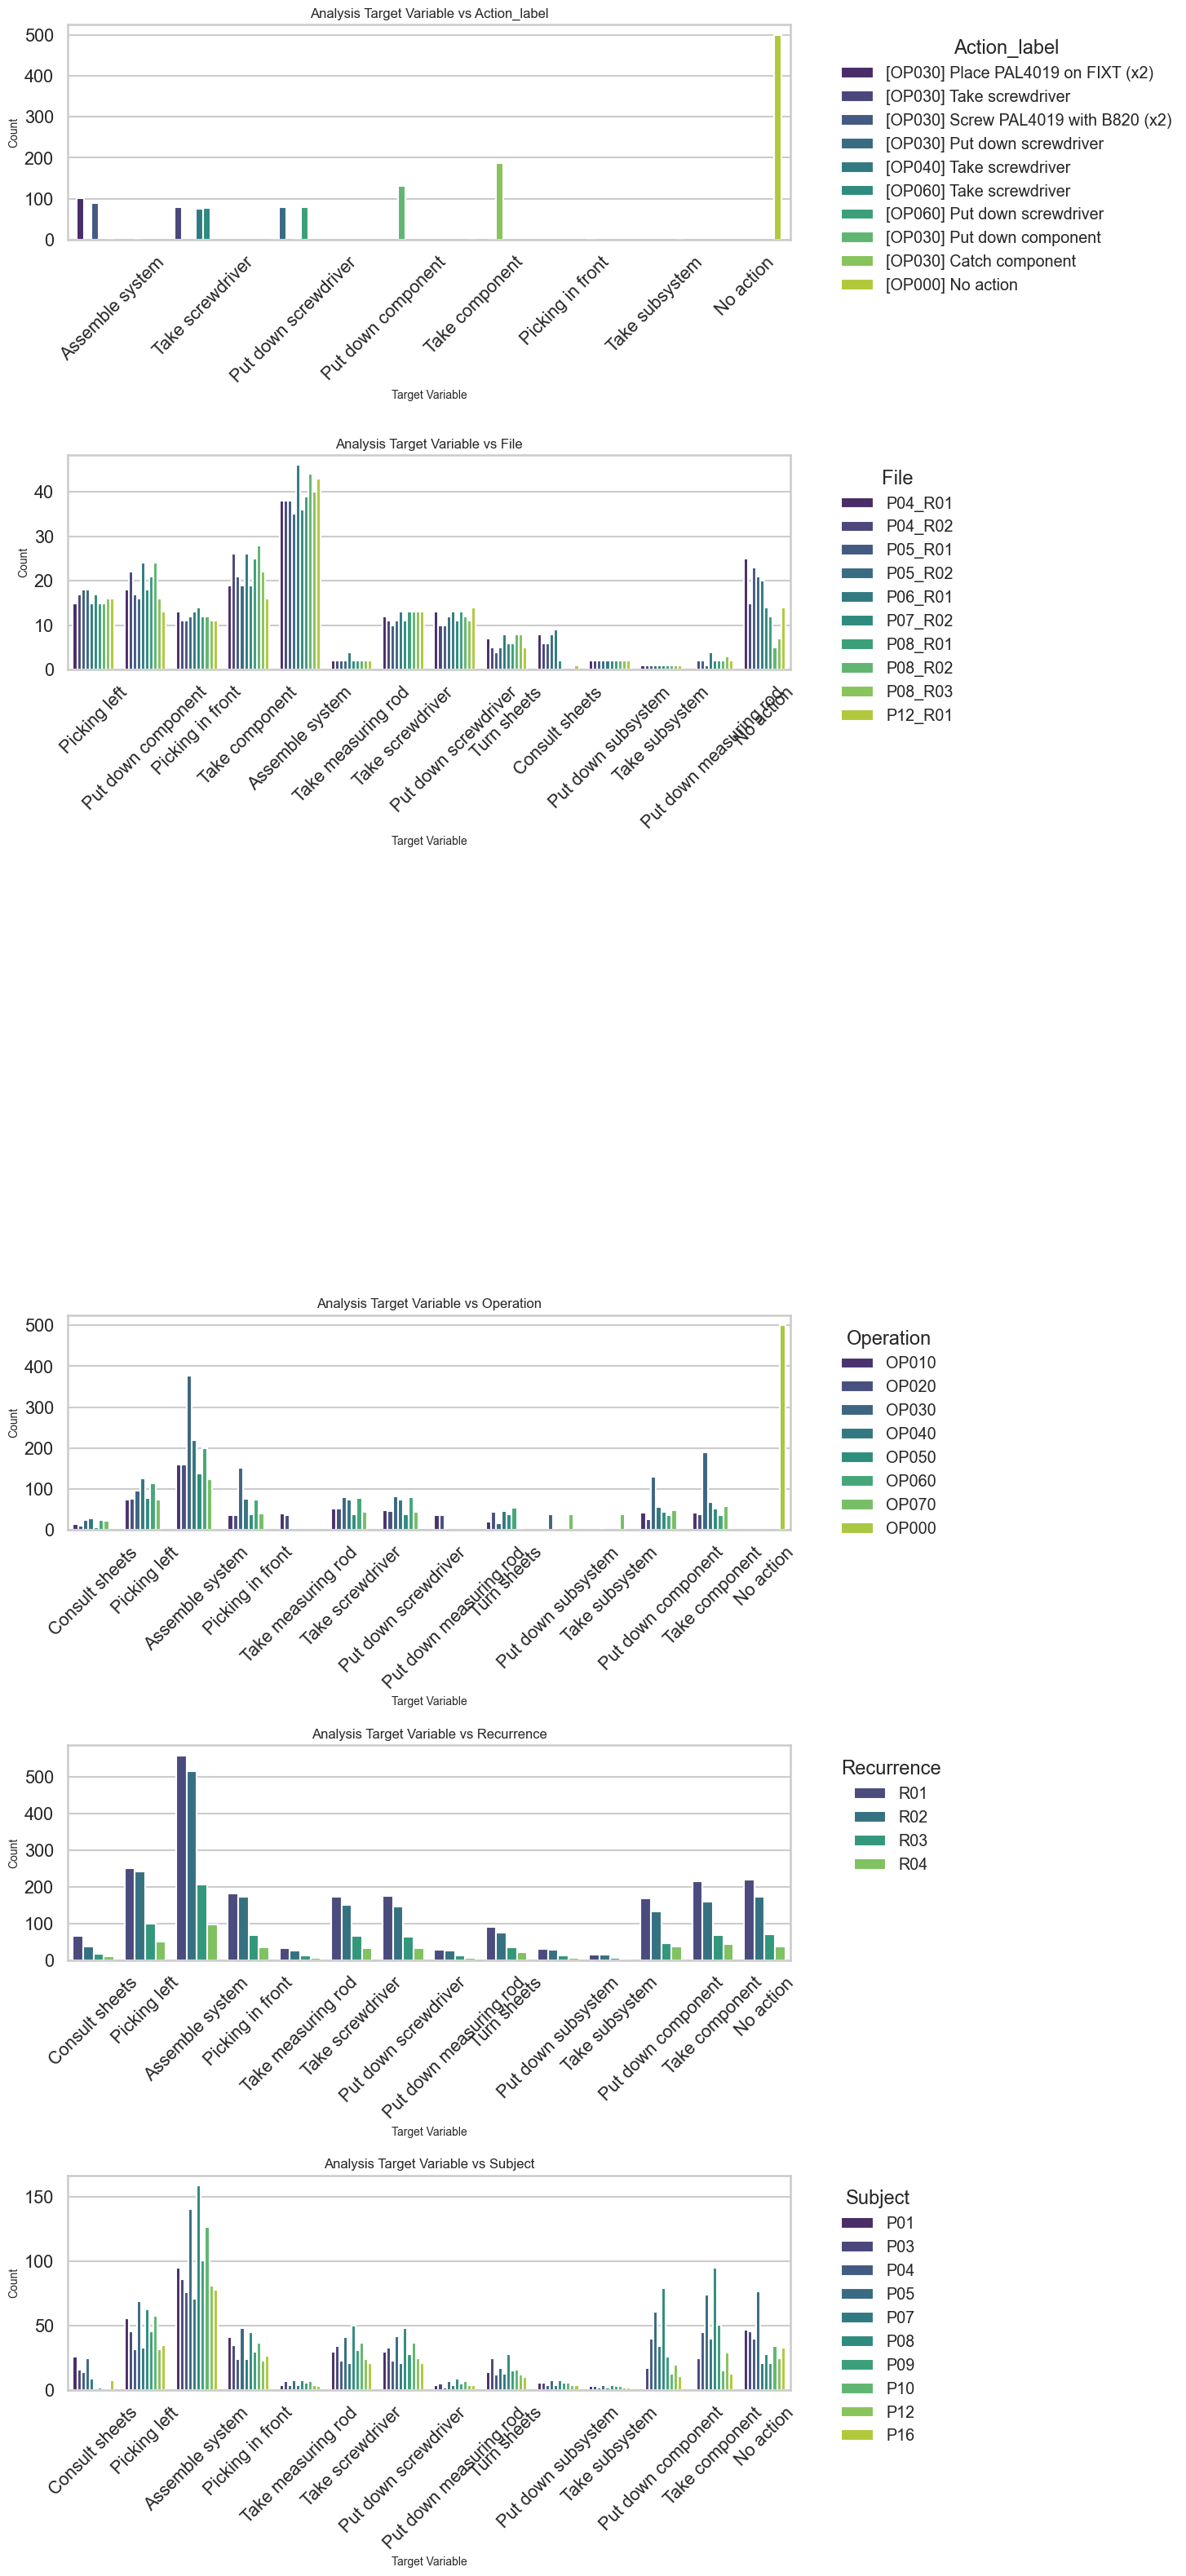

In [194]:
def plot_categorical_bivariant_analysis(df, target_col, categoric_cols):
    n_cols = 1
    n_rows = (len(categoric_cols) + 1) // n_cols
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
    
    axes = axs.ravel() if len(categoric_cols) > 1 else [axs]

    for i, (column, axe) in enumerate(zip(categoric_cols, axes)):
        if column == target_col:
            axe.set_visible(False)
            continue
            
        top_categories = df[column].value_counts().index[:10]
        temp_df = df[df[column].isin(top_categories)]

        sns.countplot(data=temp_df, x=target_col, hue=column, ax=axe, palette='viridis')
        
        axe.set_title(f'Analysis Target Variable vs {column}')
        axe.set_xlabel('Target Variable')
        axe.set_ylabel('Count')
        axe.tick_params(axis='x', rotation=45)
        
        axe.legend(title=column, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.show()

plot_categorical_bivariant_analysis(df, TARGET_VARIABLE, cat_cols)

## Conclusiones
El dataset que utilizamos para la fase de Análisis Exploratorio de Datos (EDA) fue “Industrial Human Action Recognition Dataset” (InHARD). Este set de datos contiene más de 2 millones de fotogramas (frames) de 16 sujetos distintos en entornos industriales, con el propósito de reconocer acciones humanas. Dichas acciones están clasificadas en 13 categorías. Este dataset nos permitirá entender las técnicas y modelo que debemos implementar para nuestro proyecto integrador: AI Co-Pilot for the Production Floor.

Con base en nuestro EDA, destacamos los siguientes hallazgos:
- Valores Faltantes (NaN)
No hay presencia de valores faltantes. Sin embargo, en caso de que encontremos valores faltantes, es necesario identificar si éstos son Missing Completely at Random (MCAR), Missing at Random (MAR) o Missing Not at Random (MNAR). Con base en este análisis aplicaríamos las siguientes estrategias en nuestro "pipeline" de limpieza:
    - MCAR
    El dato falta por un error puramente aleatorio e impredecible. No tiene relación con otras variables ni con el valor del dato perdido.
    *Identificación*: Si la ausencia de valores en una variable determinada está distribuida de manera uniforme en un mapa de calor.
    *Acción*: Si el porcentaje es medio o alto, imputar la media o mediana. Si el porcentaje es bajo, eliminar las filas correspondientes.
    - MAR
    Si el dato que falta es dependiente de otra variable. 
    *Identificación* Si al analizar los valores faltantes contra otras variables, se tiene una correlación alta, podemos concluir que es MAR. *Acción*: Imputar la mediana con respecto a la variable dependiente que explica el valor faltante. Podemos utilizar KNN para estimar el valor basado en las variables relacionadas. 
    - MNAR
    El dato falta por un error ligado a la variable misma.
    *Identificación*: Si los valores faltantes ocurren, en su mayoría, en los límites de los valores atípicos o eventos críticos. En esta última instancia necesitaremos tener mayor conocimiento de dominio para poderlos identificar.
    *Acción*: Crear una etiqueta o columna adicional para entrenar a nuestro modelo a comprender cuando la ausencia de un dato implica una anomalía operativa, y por ende, requiere de una alerta.

- Estadísticas resumidas (numéricas y categóricas)
En el dataset contamos con 15 variables. El 60% de éstas son numéricas, mientras que el 40% restante son categóricas.
    - Variables Numéricas:
    En su mayoría, la distribución de éstas tiene un sesgo positivo a la derecha y una distribución con curvatura mesocúrtica. Esto lo comprobamos a través de histogramas y boxplots. Dentro de la exploración encontramos que, si bien prácticaente todas las variables numéricas tienen presencia de valores atípicos, el porcentaje es bajo. En promedio se tiene un 2% de valores atípicos, únicamente en el caso de "Duration_sec" se tiene un 6%, el cual es bajo también.
    - Variables Categóricas:
    En el caso de las variables categóricas, tenemos una cardinalidad baja. Esto con excepción de la variable "Action_label". Esto hace sentido, considerando el conocimiento de dominio, donde cada acción humana tiene una distinta clasificación o movimiento realizado.

- Transformaciones
Considerando las estadísticas que encontramos para variables numéricas y categóricas, concluimos las siguientes transformaciones:

1. Eliminar Variable (s)
Las siguientes columnas o variables no agregan valor al dataset para su uso posterior en el modelo.
    - Unnamed:0

2. Manejo de Cardinalidad
Aunque solamente se identificó una variable con alta cardinalidad; requerimos agrupar los datos para tener una mejor distribución y reducir la cardinalidad en dicha variable. Esto ayudará a reducir sesgos en nuestro modelo. Los valores con menor frecuencia o relacionados entre sí, los podemos agrupar en una única categoría.
    - Action_label

3. Escalamiento de Variables Numéricas
Para aquellas variables en las cuáles identificamos valores atípicos, aplicaremos RobustScaler. Aunque el porcentaje de valores atípicos es bajo, si no los tratamos de manera adecuada, aportan únicamente ruido a nuestro modelo.
    - Duration_sec
    - Action_start_rgb_frame
    - Action_start_bvh_frame
    - Action_start_rgb_sec
    - Action_end_rgb_sec
    - Action_end_bvh_frame
    - Action_end_rgb_frame

4. Codificación de Variables Categóricas
Tanto para la variable que identificamos con alta cardinalidad, como aquellas con una cardinalidad media, requerimos codificarlas a través de One-Hot Encoding y/o LabelEncoder.
    - Action_label
    - Subject
    - File

5. Transformación de Distribución
Debido a que la mayoría de nuestras variables numéricas tienen un sesgo positivo, resulta apropiado que apliquemos una transformación logarítmica para que la distribución sea parecida a una normal.
    - Duration_sec
    - Action_end_bvh_frame
    - Action_end_rgb_sec
    - Action_end_rgb_frame
    - Action_start_bvh_frame
    - Action_start_rgb_sec
    - Action_start_rgb_frame

- Tendencias Temporales (Análisis de Sincronía y Estabilidad)
Al cruzar los datos de los sensores (BVH) con los de video (RGB), confirmamos que la captura de datos a través de video es apropiada para el proyecto. Es decir, no hay desfases en los tiempos. Al analizar las duraciones, notamos que algunos operarios se vuelven más lentos al final de sus sesiones o turnos de trabajo. Este hallazgo es clave, ya que nos da pie a concluir que nuestro modelo debe usar ventanas temporales (sliding windows) para entender cómo cambia el ritmo de trabajo por el cansancio con el paso del tiempo.

- Correlaciones & Análisis Bivariado
Existe una correlación casi unitaria ($r \approx 1.0$) entre las columnas de frames y segundos. Para los pasos posteriores de limpieza, eliminaremos las variables redundantes, conservando únicamente la variable "Duration_sec".

Identificamos una correlación entre el ID del Sujeto y la Duración. A partir de esto, concluimos que el operario o el individuo específico que está realizando una acción, determina la velocidad del proceso. Esto cobra sentido considerando que cada persona puede tardar más o menos realizando una actividad dependiendo de sus capacidades, experiencia, etc.

Debido a lo anterior, decidimos aplicar una Normalización por Sujeto (Z-score por grupo) en la fase de preprocesamiento posterior para nivelar los datos.

- Normalización de Imágenes (Nota sobre RGB)
Con base en nuestro proyecto integrador, los datos de pixeles (0-255) deberán ser normalizados al rango $[0, 1]$. Esta transformación es crítica para reducir la sensibilidad a los cambios de iluminación en el piso de producción y asegurar la convergencia del optimizador (ej. Adam) en las redes neuronales convolucionales.

- Desequilibrio de Clases
Identificamos un desequilibrio de clases alto. Las acciones de tránsito (background) están sobre las acciones atómicas de ensamblaje.
Por ello, concluimos que "Accuracy" no es una métrica válida para nuestro proyecto. Decidimos utilizar F1-Score, así como Balanced Accuracy. Adicionalmente, implementaremos técnicas de Class Weights en la función de pérdida para priorizar la detección de acciones minoritarias críticas.